# Solar Irradiance Forecasting — Full Research Notebook (Colab)

This notebook preserves the **exact working project implementations** and organizes them into a Colab-ready academic workflow.

Models included:
1. GBT
2. SVM
3. ANN
4. DNN
5. LSTM
6. CNN-DNN
7. CNN-LSTM
8. CNN-A-LSTM
9. Hybrid Residual Model


## Section 2 — Environment Setup

In [1]:
# Environment sanity check (safe imports)
import numpy as np
import pandas as pd
import requests

print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('requests:', requests.__version__)

import tensorflow as tf
print('tensorflow:', tf.__version__)
try:
    print('GPU devices:', tf.config.list_physical_devices('GPU'))
except Exception as e:
    print('GPU query warning:', e)


numpy   : 1.26.4
pandas  : 3.0.2
requests: 2.33.1
tensorflow: 2.17.0
GPU devices: []


In [2]:
# Clone/update the GitHub repository (Colab) or use local checkout (VS Code)
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/abhishekallipur/dataforlstm.git"
BRANCH = "main"

import importlib.util
IN_COLAB = importlib.util.find_spec('google.colab') is not None

if IN_COLAB:
    CLONE_DIR = "/content/dataforlstm"
    if not os.path.isdir(CLONE_DIR):
        subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, CLONE_DIR], check=True)
    else:
        subprocess.run(["git", "-C", CLONE_DIR, "fetch", "--depth", "1", "origin", BRANCH], check=False)
        subprocess.run(["git", "-C", CLONE_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=False)
else:
    # Running outside Colab (e.g., VS Code / Windows): assume this notebook is inside a local checkout.
    CLONE_DIR = str(Path.cwd())

print('IN_COLAB  :', IN_COLAB)
print('CLONE_DIR :', CLONE_DIR)


IN_COLAB  : False
CLONE_DIR : e:\OE casestudy\code


In [3]:
from pathlib import Path
import os
import sys

import importlib.util
IN_COLAB = importlib.util.find_spec('google.colab') is not None
base = Path(globals().get('CLONE_DIR') or Path.cwd()).resolve()

# Prefer colab_ready if it contains the python packages; fallback to repo root.
candidates = [base / 'colab_ready', base]
PROJECT_ROOT = None
for p in candidates:
    if (p / 'benchmark').is_dir() and (p / 'models').is_dir():
        PROJECT_ROOT = str(p.resolve())
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find project root containing benchmark/ and models/. Checked: {candidates}"
    )

# Ensure all relative outputs/... paths in project code resolve under the project root.
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Dataset path: allow override via env var, otherwise look for dataset/ in common places.
DATA_PATH = os.environ.get('DATA_PATH', '').strip()
if not DATA_PATH:
    for dp in [Path(PROJECT_ROOT) / 'dataset', base / 'dataset']:
        if dp.is_dir():
            DATA_PATH = str(dp.resolve())
            break

if not DATA_PATH or not Path(DATA_PATH).is_dir():
    raise FileNotFoundError(
        f"DATA_PATH not found. Tried {Path(PROJECT_ROOT)/'dataset'} and {base/'dataset'}. "
        "Set env var DATA_PATH to your dataset folder."
    )

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_PATH     =', DATA_PATH)
print('CWD           =', Path.cwd())
print('has benchmark =', (Path(PROJECT_ROOT) / 'benchmark').is_dir())
print('has models    =', (Path(PROJECT_ROOT) / 'models').is_dir())
print('csv count     =', len(list(Path(DATA_PATH).glob('*.csv'))))


PROJECT_ROOT = E:\OE casestudy\code\colab_ready
DATA_PATH     = E:\OE casestudy\code\colab_ready\dataset
CWD           = E:\OE casestudy\code\colab_ready
has benchmark = True
has models    = True
csv count     = 4


In [4]:
from pathlib import Path
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("benchmark:", os.path.exists(f"{PROJECT_ROOT}/benchmark"))
print("models   :", os.path.exists(f"{PROJECT_ROOT}/models"))
print("dataset  :", os.path.exists(DATA_PATH))
print("requirements:", os.path.exists(f"{PROJECT_ROOT}/requirements.txt"))

PROJECT_ROOT = E:\OE casestudy\code\colab_ready
benchmark: True
models   : True
dataset  : True
requirements: True


In [5]:
from benchmark.config import set_global_seed

In [6]:
# Imports, seed, GPU
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is importable before benchmark imports
if 'PROJECT_ROOT' not in globals() or not PROJECT_ROOT:
    # Fallback only if earlier cells didn't set PROJECT_ROOT
    PROJECT_ROOT = globals().get('PROJECT_ROOT') or globals().get('CLONE_DIR') or os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from benchmark.config import (
    set_global_seed,
    EvalConfig,
    GBTConfig,
    SVMConfig,
    ANNConfig,
    DNNConfig,
    LSTMConfig,
    CNNDNNConfig,
    CNNLSTMConfig,
    CNNAttentionLSTMConfig,
)
from benchmark.data_loader import load_raw_nsrdb, load_benchmark_data
from benchmark.features import TABULAR_FEATURES, SEQUENCE_FEATURES
from benchmark.splitter import build_tabular_bundle, build_sequence_bundle
from benchmark.evaluation import compute_metrics, compute_regime_metrics, build_comparison_table

from benchmark.models.gbt import GBTForecaster
from benchmark.models.svm import SVMForecaster
from benchmark.models.ann import ANNForecaster
from benchmark.models.dnn import DNNForecaster
from benchmark.models.lstm import LSTMForecaster
from benchmark.models.cnn_dnn import CNNDNNForecaster
from benchmark.models.cnn_lstm import CNNLSTMForecaster
from benchmark.models.cnn_attention_lstm import CNNAttentionLSTMForecaster

set_global_seed(42)

try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
    print("GPU devices:", tf.config.list_physical_devices("GPU"))
except Exception as e:
    print("TensorFlow import warning:", e)

TensorFlow: 2.17.0
GPU devices: []


## Section 3 — GitHub Repository Setup

In [7]:
# Repo-only path setup (no Drive)
import os
import sys

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_PATH:', DATA_PATH)
print('dataset exists:', os.path.isdir(DATA_PATH))
print('csv count:', len([f for f in os.listdir(DATA_PATH) if f.lower().endswith('.csv')]))

PROJECT_ROOT: E:\OE casestudy\code\colab_ready
DATA_PATH: E:\OE casestudy\code\colab_ready\dataset
dataset exists: True
csv count: 4


## Section 4 — Dataset Loading

In [8]:
# Dataset loading check from repo path
print("DATA_PATH =", DATA_PATH)

import os
print("exists:", os.path.exists(DATA_PATH))
print("csv count:", len([f for f in os.listdir(DATA_PATH) if f.lower().endswith(".csv")]))

DATA_PATH = E:\OE casestudy\code\colab_ready\dataset
exists: True
csv count: 4


In [9]:
# Full enriched benchmark dataset (exact project pipeline)
DF = load_benchmark_data(DATA_PATH, extra_features=True)
DF['timestamp'] = pd.to_datetime(DF['timestamp'])
DF = DF.sort_values('timestamp').reset_index(drop=True)
print('ENRICHED shape:', DF.shape)
print('ENRICHED NaN count:', int(DF.isna().sum().sum()))
DF.head()


ENRICHED shape: (35064, 46)
ENRICHED NaN count: 0


,timestamp,ghi,temperature,relative_humidity,wind_speed,pressure,solar_zenith_angle,hour,sin_hour,cos_hour,...,ghi_gradient_accel,ghi_roll_min_24,ghi_roll_max_24,ghi_roll_range_24,ghi_roll_var_3,ghi_roll_var_6,regime_id,regime_clear,regime_partly_cloudy,regime_cloudy
0,2018-01-01 00:00:00,119,16.1,38.06,0.9,974,168.944727,0.0,0.000000,1.000000,...,0.000000,0.0,0.0,0.0,0.000000,2360.166667,2,0.0,0.0,1.0
1,2018-01-01 01:00:00,0,14.5,47.66,0.9,975,162.226497,1.0,0.258819,0.965926,...,0.000000,0.0,0.0,0.0,0.000000,2360.166667,2,0.0,0.0,1.0
2,2018-01-01 02:00:00,0,13.7,54.29,1.1,975,150.835539,2.0,0.500000,0.866025,...,0.000000,0.0,0.0,0.0,4720.333333,2360.166667,2,0.0,0.0,1.0
3,2018-01-01 03:00:00,0,13.3,56.27,1.3,976,138.562990,3.0,0.707107,0.707107,...,0.000000,0.0,0.0,0.0,0.000000,2360.166667,2,0.0,0.0,1.0
4,2018-01-01 04:00:00,0,12.9,54.83,1.3,976,126.161160,4.0,0.866025,0.500000,...,39.666667,0.0,0.0,0.0,0.000000,2360.166667,2,0.0,0.0,1.0


## Section 5 — Feature Engineering

In [10]:
# Exact project feature lists
TAB_FEATURES_ACTIVE = [f for f in TABULAR_FEATURES if f in DF.columns]
SEQ_FEATURES_ACTIVE = [f for f in SEQUENCE_FEATURES if f in DF.columns]

print('Tabular features:', len(TAB_FEATURES_ACTIVE))
print('Sequence features:', len(SEQ_FEATURES_ACTIVE))


Tabular features: 43
Sequence features: 28


## Section 6 — Train / Validation / Test Split

In [11]:
# Chronological split + leakage-safe scaling (exact splitter)
TAB_BUNDLE = build_tabular_bundle(DF, TAB_FEATURES_ACTIVE, train_ratio=0.70, val_ratio=0.15)
SEQ_BUNDLE = build_sequence_bundle(DF, SEQ_FEATURES_ACTIVE, sequence_length=48, train_ratio=0.70, val_ratio=0.15)

print('Tabular:', TAB_BUNDLE.X_train.shape, TAB_BUNDLE.X_val.shape, TAB_BUNDLE.X_test.shape)
print('Sequence:', SEQ_BUNDLE.X_train.shape, SEQ_BUNDLE.X_val.shape, SEQ_BUNDLE.X_test.shape)


Tabular: (24544, 43) (5260, 43) (5260, 43)
Sequence: (24496, 48, 28) (5260, 48, 28) (5260, 48, 28)


## Section 7 — Shared Utilities

In [12]:
def evaluate_on_tabular_test(y_true_raw, y_pred_raw, bundle):
    return compute_metrics(
        y_true=y_true_raw,
        y_pred=y_pred_raw,
        peak_threshold=bundle.peak_threshold_raw,
        timestamps=bundle.test_timestamps,
        is_daylight=bundle.is_daylight_test,
        regime_ids=bundle.regime_id_test,
    )


def evaluate_on_sequence_test(y_true_raw, y_pred_raw, bundle):
    return compute_metrics(
        y_true=y_true_raw,
        y_pred=y_pred_raw,
        peak_threshold=bundle.peak_threshold_raw,
        timestamps=bundle.test_timestamps,
        is_daylight=bundle.is_daylight_test,
        regime_ids=bundle.regime_id_test,
    )


def regime_metrics_on_tabular_test(y_true_raw, y_pred_raw, bundle):
    return compute_regime_metrics(
        y_true=y_true_raw,
        y_pred=y_pred_raw,
        regime_ids=bundle.regime_id_test,
        peak_threshold=bundle.peak_threshold_raw,
        is_daylight=bundle.is_daylight_test,
    )


def regime_metrics_on_sequence_test(y_true_raw, y_pred_raw, bundle):
    return compute_regime_metrics(
        y_true=y_true_raw,
        y_pred=y_pred_raw,
        regime_ids=bundle.regime_id_test,
        peak_threshold=bundle.peak_threshold_raw,
        is_daylight=bundle.is_daylight_test,
    )


## Section 8 — Model Implementations

### MODEL 1 — GBT

In [13]:
gbt_model = GBTForecaster(
    config=GBTConfig(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=20,
        feature_fraction=0.85,
        subsample=0.85,
        reg_alpha=0.0,
        reg_lambda=0.1,
        early_stopping_rounds=100,
    ),
    feature_names=TAB_FEATURES_ACTIVE,
)


In [14]:
gbt_history = gbt_model.fit(TAB_BUNDLE.X_train, TAB_BUNDLE.y_train, TAB_BUNDLE.X_val, TAB_BUNDLE.y_val)
gbt_history


{'best_iteration': 2000}

In [15]:
gbt_pred_scaled = gbt_model.predict(TAB_BUNDLE.X_test)
gbt_pred_raw = TAB_BUNDLE.target_scaler.inverse_transform(gbt_pred_scaled.reshape(-1, 1)).reshape(-1)


e:\OE casestudy\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [16]:
gbt_metrics = evaluate_on_tabular_test(TAB_BUNDLE.y_test_raw, gbt_pred_raw, TAB_BUNDLE)
gbt_regime_metrics = regime_metrics_on_tabular_test(TAB_BUNDLE.y_test_raw, gbt_pred_raw, TAB_BUNDLE)
print(gbt_metrics)
gbt_regime_metrics


{'rmse': 6.756267374369342, 'mae': 2.3669474602241567, 'r2': 0.9995643373800669, 'day_mae': 0.9535284091895226, 'peak_mae': 4.992189047642631, 'cloud_mae': 0.29273675674487115, 'transition_mae': 2.221288010425678}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,6.209664,3.735767,0.459838,4.309766
1,partly_cloudy,55,2.686910,2.043416,0.606090,NaN
2,cloudy,4719,6.842873,2.229746,-0.025977,5.233819


### MODEL 2 — SVM

In [17]:
svm_model = SVMForecaster(
    config=SVMConfig(kernel='rbf', C=100.0, epsilon=0.1, gamma='scale', max_train_samples=8000)
)


In [18]:
svm_history = svm_model.fit(TAB_BUNDLE.X_train, TAB_BUNDLE.y_train, TAB_BUNDLE.X_val, TAB_BUNDLE.y_val)
svm_history


{'train_samples_used': 8458, 'n_support_vectors': 129}

In [19]:
svm_pred_scaled = svm_model.predict(TAB_BUNDLE.X_test)
svm_pred_raw = TAB_BUNDLE.target_scaler.inverse_transform(svm_pred_scaled.reshape(-1, 1)).reshape(-1)


In [20]:
svm_metrics = evaluate_on_tabular_test(TAB_BUNDLE.y_test_raw, svm_pred_raw, TAB_BUNDLE)
svm_regime_metrics = regime_metrics_on_tabular_test(TAB_BUNDLE.y_test_raw, svm_pred_raw, TAB_BUNDLE)
print(svm_metrics)
svm_regime_metrics


{'rmse': 50.08899001270917, 'mae': 41.79030909762348, 'r2': 0.9760546498506127, 'day_mae': 40.4564001484035, 'peak_mae': 38.38227343672618, 'cloud_mae': 42.486584398802975, 'transition_mae': 39.12668244110355}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,40.168447,31.134399,3.354214,26.900414
1,partly_cloudy,55,52.748526,43.947102,-9.245016,NaN
2,cloudy,4719,50.969940,42.862598,17.454063,42.447735


### MODEL 3 — ANN

In [21]:
ann_model = ANNForecaster(
    config=ANNConfig(hidden_units=[128, 64], dropout_rate=0.2, learning_rate=1e-3, epochs=100, batch_size=128, patience=15)
)


In [22]:
ann_history = ann_model.fit(TAB_BUNDLE.X_train, TAB_BUNDLE.y_train, TAB_BUNDLE.X_val, TAB_BUNDLE.y_val)
ann_history




Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 33: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 38: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 30.


{'best_epoch': 30}

In [23]:
ann_pred_scaled = ann_model.predict(TAB_BUNDLE.X_test)
ann_pred_raw = TAB_BUNDLE.target_scaler.inverse_transform(ann_pred_scaled.reshape(-1, 1)).reshape(-1)


In [24]:
ann_metrics = evaluate_on_tabular_test(TAB_BUNDLE.y_test_raw, ann_pred_raw, TAB_BUNDLE)
ann_regime_metrics = regime_metrics_on_tabular_test(TAB_BUNDLE.y_test_raw, ann_pred_raw, TAB_BUNDLE)
print(ann_metrics)
ann_regime_metrics


{'rmse': 9.152927399378697, 'mae': 6.695102515680708, 'r2': 0.9992004296561033, 'day_mae': 6.215790733127473, 'peak_mae': 9.009010327032364, 'cloud_mae': 5.4430089095345044, 'transition_mae': 6.963563491246691}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,11.792999,9.049153,-6.307662,10.209939
1,partly_cloudy,55,15.686266,11.205256,-3.054589,NaN
2,cloudy,4719,8.728664,6.400098,1.426041,8.583789


### MODEL 4 — DNN

In [25]:
dnn_model = DNNForecaster(
    config=DNNConfig(hidden_units=[256, 128, 64, 32], dropout_rates=[0.3, 0.3, 0.2, 0.1], use_batch_norm=True, learning_rate=1e-3, epochs=120, batch_size=128, patience=15)
)


In [26]:
dnn_history = dnn_model.fit(TAB_BUNDLE.X_train, TAB_BUNDLE.y_train, TAB_BUNDLE.X_val, TAB_BUNDLE.y_val)
dnn_history



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 34: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 39: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 44: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 49: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 54: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 59: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 64: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 97: early stopping
Restoring model weights from the end of the best epoch: 82.


{'best_epoch': 82}

In [27]:
dnn_pred_scaled = dnn_model.predict(TAB_BUNDLE.X_test)
dnn_pred_raw = TAB_BUNDLE.target_scaler.inverse_transform(dnn_pred_scaled.reshape(-1, 1)).reshape(-1)


In [28]:
dnn_metrics = evaluate_on_tabular_test(TAB_BUNDLE.y_test_raw, dnn_pred_raw, TAB_BUNDLE)
dnn_regime_metrics = regime_metrics_on_tabular_test(TAB_BUNDLE.y_test_raw, dnn_pred_raw, TAB_BUNDLE)
print(dnn_metrics)
dnn_regime_metrics


{'rmse': 11.451172613225092, 'mae': 7.43256279224452, 'r2': 0.9987484835423895, 'day_mae': 5.775568160928836, 'peak_mae': 10.042283531225237, 'cloud_mae': 4.7703869632878035, 'transition_mae': 7.363766730123113}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,13.845828,9.727036,-0.107441,8.761886
1,partly_cloudy,55,15.770222,9.914818,-0.682026,NaN
2,cloudy,4719,11.113969,7.167329,-0.115262,10.495644


### MODEL 5 — LSTM

In [29]:
lstm_model = LSTMForecaster(
    config=LSTMConfig(units=[64, 32], dropout_rate=0.2, dense_units=16, learning_rate=1e-3, epochs=80, batch_size=128, patience=12)
)


In [30]:
lstm_history = lstm_model.fit(SEQ_BUNDLE.X_train, SEQ_BUNDLE.y_train, SEQ_BUNDLE.X_val, SEQ_BUNDLE.y_val)
lstm_history



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 5.


{'best_epoch': 13}

In [31]:
lstm_pred_scaled = lstm_model.predict(SEQ_BUNDLE.X_test)
lstm_pred_raw = SEQ_BUNDLE.target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).reshape(-1)


In [32]:
lstm_metrics = evaluate_on_sequence_test(SEQ_BUNDLE.y_test_raw, lstm_pred_raw, SEQ_BUNDLE)
lstm_regime_metrics = regime_metrics_on_sequence_test(SEQ_BUNDLE.y_test_raw, lstm_pred_raw, SEQ_BUNDLE)
print(lstm_metrics)
lstm_regime_metrics


{'rmse': 54.44337400047245, 'mae': 23.040374954979683, 'r2': 0.9717104065602328, 'day_mae': 17.528246962196175, 'peak_mae': 32.781292816792835, 'cloud_mae': 10.3891308944695, 'transition_mae': 25.63346523267971}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,75.257935,42.948257,7.372340,41.276878
1,partly_cloudy,55,117.778957,70.294884,17.039083,NaN
2,cloudy,4719,50.585732,20.439350,7.640743,29.760233


### MODEL 6 — CNN-DNN

In [33]:
cnn_dnn_model = CNNDNNForecaster(
    config=CNNDNNConfig(conv_filters=[64, 32], kernel_size=3, dense_units=[64, 32], dropout_rate=0.3, learning_rate=1e-3, epochs=100, batch_size=128, patience=12)
)


In [34]:
cnn_dnn_history = cnn_dnn_model.fit(SEQ_BUNDLE.X_train, SEQ_BUNDLE.y_train, SEQ_BUNDLE.X_val, SEQ_BUNDLE.y_val)
cnn_dnn_history



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 19.


{'best_epoch': 19}

In [35]:
cnn_dnn_pred_scaled = cnn_dnn_model.predict(SEQ_BUNDLE.X_test)
cnn_dnn_pred_raw = SEQ_BUNDLE.target_scaler.inverse_transform(cnn_dnn_pred_scaled.reshape(-1, 1)).reshape(-1)


In [36]:
cnn_dnn_metrics = evaluate_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_dnn_pred_raw, SEQ_BUNDLE)
cnn_dnn_regime_metrics = regime_metrics_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_dnn_pred_raw, SEQ_BUNDLE)
print(cnn_dnn_metrics)
cnn_dnn_regime_metrics


{'rmse': 52.62129171226515, 'mae': 22.36721172920878, 'r2': 0.973572282734518, 'day_mae': 16.395808909747743, 'peak_mae': 38.41547208218961, 'cloud_mae': 7.165042494801534, 'transition_mae': 25.4649306512456}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,78.657675,49.723904,-25.573290,45.626671
1,partly_cloudy,55,110.500477,80.553894,-15.939941,NaN
2,cloudy,4719,48.030673,18.871635,-2.054961,35.851147


### MODEL 7 — CNN-LSTM

In [37]:
cnn_lstm_model = CNNLSTMForecaster(
    config=CNNLSTMConfig(conv_filters=[64, 32], kernel_size=3, lstm_units=[64, 32], dense_units=16, dropout_rate=0.2, learning_rate=1e-3, epochs=100, batch_size=128, patience=12)
)


In [38]:
cnn_lstm_history = cnn_lstm_model.fit(SEQ_BUNDLE.X_train, SEQ_BUNDLE.y_train, SEQ_BUNDLE.X_val, SEQ_BUNDLE.y_val)
cnn_lstm_history



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 12.


{'best_epoch': 12}

In [39]:
cnn_lstm_pred_scaled = cnn_lstm_model.predict(SEQ_BUNDLE.X_test)
cnn_lstm_pred_raw = SEQ_BUNDLE.target_scaler.inverse_transform(cnn_lstm_pred_scaled.reshape(-1, 1)).reshape(-1)


In [40]:
cnn_lstm_metrics = evaluate_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_lstm_pred_raw, SEQ_BUNDLE)
cnn_lstm_regime_metrics = regime_metrics_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_lstm_pred_raw, SEQ_BUNDLE)
print(cnn_lstm_metrics)
cnn_lstm_regime_metrics


{'rmse': 51.06218268147461, 'mae': 19.08499695468878, 'r2': 0.9751151290635748, 'day_mae': 14.887561027964965, 'peak_mae': 30.681241992168093, 'cloud_mae': 6.848736544510556, 'transition_mae': 23.50086114784846}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,79.818217,44.759388,-13.285762,41.015961
1,partly_cloudy,55,100.285832,63.274117,-1.812755,NaN
2,cloudy,4719,46.183464,15.925820,1.716866,27.006182


### MODEL 8 — CNN-A-LSTM

In [41]:
cnn_a_lstm_model = CNNAttentionLSTMForecaster(
    config=CNNAttentionLSTMConfig(conv_filters=[64, 32], kernel_size=3, lstm_units=[64, 32], attention_units=32, dense_units=32, dropout_rate=0.2, learning_rate=1e-3, epochs=100, batch_size=128, patience=12)
)


In [42]:
cnn_a_lstm_history = cnn_a_lstm_model.fit(SEQ_BUNDLE.X_train, SEQ_BUNDLE.y_train, SEQ_BUNDLE.X_val, SEQ_BUNDLE.y_val)
cnn_a_lstm_history



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 19.


{'best_epoch': 19}

In [43]:
cnn_a_lstm_pred_scaled = cnn_a_lstm_model.predict(SEQ_BUNDLE.X_test)
cnn_a_lstm_pred_raw = SEQ_BUNDLE.target_scaler.inverse_transform(cnn_a_lstm_pred_scaled.reshape(-1, 1)).reshape(-1)
attention_weights = cnn_a_lstm_model.get_attention_weights(SEQ_BUNDLE.X_test[:100])
print('attention_weights shape:', attention_weights.shape)


attention_weights shape: (100, 48, 1)


In [44]:
cnn_a_lstm_metrics = evaluate_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_a_lstm_pred_raw, SEQ_BUNDLE)
cnn_a_lstm_regime_metrics = regime_metrics_on_sequence_test(SEQ_BUNDLE.y_test_raw, cnn_a_lstm_pred_raw, SEQ_BUNDLE)
print(cnn_a_lstm_metrics)
cnn_a_lstm_regime_metrics


{'rmse': 55.84778616737409, 'mae': 22.33727298343816, 'r2': 0.9702320747193718, 'day_mae': 17.163261616080888, 'peak_mae': 34.153065643553134, 'cloud_mae': 8.796568246508626, 'transition_mae': 26.29013913303536}


,regime,count,rmse,mae,bias,peak_mae
0,clear,486,78.839331,45.660412,-5.084441,44.507343
1,partly_cloudy,55,154.740673,90.436150,15.941221,NaN
2,cloudy,4719,50.570075,19.141579,1.964309,30.471048


### MODEL 9 — HYBRID RESIDUAL MODEL

In [45]:
from models.residual_hybrid.model import run_pipeline as run_hybrid_residual_pipeline


In [46]:
from pathlib import Path
import os

os.chdir(PROJECT_ROOT)

# Ensure output dirs exist (the pipeline writes relative outputs/... paths)
(Path(PROJECT_ROOT) / 'outputs' / 'reports').mkdir(parents=True, exist_ok=True)
(Path(PROJECT_ROOT) / 'outputs' / 'artifacts').mkdir(parents=True, exist_ok=True)

baseline_model_path = Path(PROJECT_ROOT) / 'outputs' / 'artifacts' / 'task_d_baseline_aggressive_peak_2x.h5'
retrain_baseline = not baseline_model_path.exists()

print('CWD:', Path.cwd())
print('Baseline model path:', baseline_model_path)
print('Baseline exists:', baseline_model_path.exists())
print('retrain_baseline:', retrain_baseline)

hybrid_summary = run_hybrid_residual_pipeline(
    data_path=DATA_PATH,
    sequence_length=48,
    train_ratio=0.70,
    val_ratio=0.15,
    baseline_model_path=str(baseline_model_path),
    baseline_learning_rate=1e-3,
    baseline_epochs=80,
    baseline_batch_size=128,
    ensemble_size=3,
    walk_forward_splits=4,
    seed=42,
    retrain_baseline=retrain_baseline,
    compare_optional_models=False,
    no_plot=True,
)


CWD: E:\OE casestudy\code\colab_ready
Baseline model path: E:\OE casestudy\code\colab_ready\outputs\artifacts\task_d_baseline_aggressive_peak_2x.h5
Baseline exists: True
retrain_baseline: False

Residual hybrid summary
Baseline RMSE: 53.80, Peak MAE: 25.84
Hybrid RMSE:   8.18, Peak MAE: 5.39
Hybrid Day MAE: 6.37
Peak hour MAE:  1.50
Reports saved to: outputs/reports/residual_hybrid_report.json


In [47]:
from pathlib import Path
import os
import pandas as pd

os.chdir(PROJECT_ROOT)

pred_path = Path(PROJECT_ROOT) / 'outputs' / 'reports' / 'residual_hybrid_predictions.csv'
print('CWD:', Path.cwd())
print('Expecting hybrid predictions at:', pred_path)

if not pred_path.exists():
    reports_dir = Path(PROJECT_ROOT) / 'outputs' / 'reports'
    existing = sorted([p.name for p in reports_dir.glob('*')]) if reports_dir.exists() else []
    raise FileNotFoundError(
        "Hybrid predictions CSV not found: {}\nReports dir contents: {}\nHybrid pipeline likely failed earlier or wrote to a different working directory. Re-run the Hybrid Residual Model cell and ensure it completes without errors.".format(
            pred_path, existing
        )
    )

hybrid_predictions = pd.read_csv(pred_path)
hybrid_predictions[['timestamp','actual_ghi','baseline_pred','residual_pred','calibrated_residual','hybrid_pred']].head()


CWD: E:\OE casestudy\code\colab_ready
Expecting hybrid predictions at: E:\OE casestudy\code\colab_ready\outputs\reports\residual_hybrid_predictions.csv


,timestamp,actual_ghi,baseline_pred,residual_pred,calibrated_residual,hybrid_pred
0,2018-01-04 00:00:00,65,62.182846,2.975394,3.455197,65.638043
1,2018-01-04 01:00:00,0,18.660732,-19.370485,-20.046138,0.000000
2,2018-01-04 02:00:00,0,6.548243,-6.417352,-6.423227,0.125017
3,2018-01-04 03:00:00,0,3.604811,-4.580218,-4.491099,0.000000
4,2018-01-04 04:00:00,0,2.697112,-2.170205,-1.956469,0.740643


In [48]:
hybrid_metrics = hybrid_summary['hybrid_test']
print('Baseline:', hybrid_summary['baseline_test'])
print('Hybrid  :', hybrid_summary['hybrid_test'])
print('Peak hrs:', hybrid_summary['peak_hour_metrics'])


Baseline: {'rmse': 53.79871747498378, 'mae': 21.075899124145508, 'r2': 0.9723227024078369, 'day_mae': 36.326045989990234, 'peak_mae': 25.836687088012695}
Hybrid  : {'rmse': 8.182356326934395, 'mae': 3.3131480955187054, 'r2': 0.999359769349151, 'day_mae': 6.366012113247456, 'peak_mae': 5.388964738706633}
Peak hrs: {'baseline_peak_hour_mae': 14.440208435058594, 'hybrid_peak_hour_mae': 1.4982973175150867}


## Section 9 — Model Comparison

In [49]:
ALL_METRICS = {
    'GBT (LightGBM)': gbt_metrics,
    'SVM (SVR-RBF)': svm_metrics,
    'ANN': ann_metrics,
    'DNN': dnn_metrics,
    'LSTM': lstm_metrics,
    'CNN-DNN': cnn_dnn_metrics,
    'CNN-LSTM': cnn_lstm_metrics,
    'CNN-A-LSTM': cnn_a_lstm_metrics,
    'Hybrid Residual': hybrid_metrics,
}
comparison_df = build_comparison_table(ALL_METRICS, EvalConfig())
comparison_df


,model,rmse,mae,r2,day_mae,peak_mae,cloud_mae,transition_mae,composite_score,rank
0,GBT (LightGBM),6.756267,2.366947,0.999564,0.953528,4.992189,0.292737,2.221288,3.875811,1
1,Hybrid Residual,8.182356,3.313148,0.999360,6.366012,5.388965,NaN,NaN,4.195129,2
2,ANN,9.152927,6.695103,0.999200,6.215791,9.009010,5.443009,6.963563,7.747687,3
3,DNN,11.451173,7.432563,0.998748,5.775568,10.042284,4.770387,7.363767,8.750444,4
4,CNN-LSTM,51.062183,19.084997,0.975115,14.887561,30.681242,6.848737,23.500861,29.824342,5
5,CNN-DNN,52.621292,22.367212,0.973572,16.395809,38.415472,7.165042,25.464931,32.837420,6
6,LSTM,54.443374,23.040375,0.971710,17.528247,32.781293,10.389131,25.633465,32.900735,7
7,CNN-A-LSTM,55.847786,22.337273,0.970232,17.163262,34.153066,8.796568,26.290139,33.315410,8
8,SVM (SVR-RBF),50.088990,41.790309,0.976055,40.456400,38.382273,42.486584,39.126682,43.303204,9


## Section 10 — Visualization Section

In [63]:
import importlib.util
from pathlib import Path

PROJECT_ROOT = Path(globals().get('PROJECT_ROOT') or Path.cwd()).resolve()

# In this repo, PROJECT_ROOT often points to .../colab_ready, but figures may also live in repo-root outputs/figures
candidate_roots = [PROJECT_ROOT, PROJECT_ROOT.parent]
fig_file = None
for root in candidate_roots:
    cand = root / 'outputs' / 'figures' / 'generate_publication_figures.py'
    if cand.exists():
        fig_file = cand
        break

if fig_file is None:
    # Colab safety-net: if the figures module wasn't packaged into the cloned repo,
    # fetch the exact implementation from the source repository and write it locally.
    import urllib.request

    fallback_url = (
        'https://raw.githubusercontent.com/abhishekallipur/'
        'LSTM-Solar-Irradiance-Prediction/main/outputs/figures/'
        'generate_publication_figures.py'
    )
    dest = candidate_roots[0] / 'outputs' / 'figures' / 'generate_publication_figures.py'
    dest.parent.mkdir(parents=True, exist_ok=True)

    try:
        urllib.request.urlretrieve(fallback_url, dest)
        fig_file = dest
        print('Downloaded generate_publication_figures.py to:', dest)
    except Exception as e:
        tried = [str(r / 'outputs' / 'figures' / 'generate_publication_figures.py') for r in candidate_roots]
        raise FileNotFoundError(
            'generate_publication_figures.py not found. Tried: '
            + ' | '.join(tried)
            + f" ; and fallback download failed: {e}"
        )

spec = importlib.util.spec_from_file_location('generate_publication_figures', fig_file)
mod = importlib.util.module_from_spec(spec)
assert spec and spec.loader
spec.loader.exec_module(mod)

# Expose directories for downstream cells
REPO_ROOT = fig_file.resolve().parents[2]          # <repo>/
OUTPUTS_DIR = fig_file.resolve().parents[1]        # <repo>/outputs/
FIGURES_DIR = fig_file.resolve().parent            # <repo>/outputs/figures/

fig1_correlation_heatmap = mod.fig1_correlation_heatmap
fig2_actual_vs_predicted = mod.fig2_actual_vs_predicted
fig3_model_performance = mod.fig3_model_performance
fig4_clear_sky = mod.fig4_clear_sky
fig5_cloudy_sky = mod.fig5_cloudy_sky
fig6_feature_importance = mod.fig6_feature_importance
fig7_attention_weights = mod.fig7_attention_weights
fig8_recursive_drift = mod.fig8_recursive_drift
fig9_residual_distribution = mod.fig9_residual_distribution
fig10_leakage_impact = mod.fig10_leakage_impact
fig11_regime_performance = mod.fig11_regime_performance

from IPython.display import Image, display
print('Loaded generate_publication_figures from:', fig_file)
print('FIGURES_DIR =', FIGURES_DIR)


Loaded generate_publication_figures from: E:\OE casestudy\code\outputs\figures\generate_publication_figures.py
FIGURES_DIR = E:\OE casestudy\code\outputs\figures


### 1. Correlation heatmap

Saved figure_1_correlation_heatmap
Saved: E:\OE casestudy\code\outputs\figures\figure_1_correlation_heatmap.png


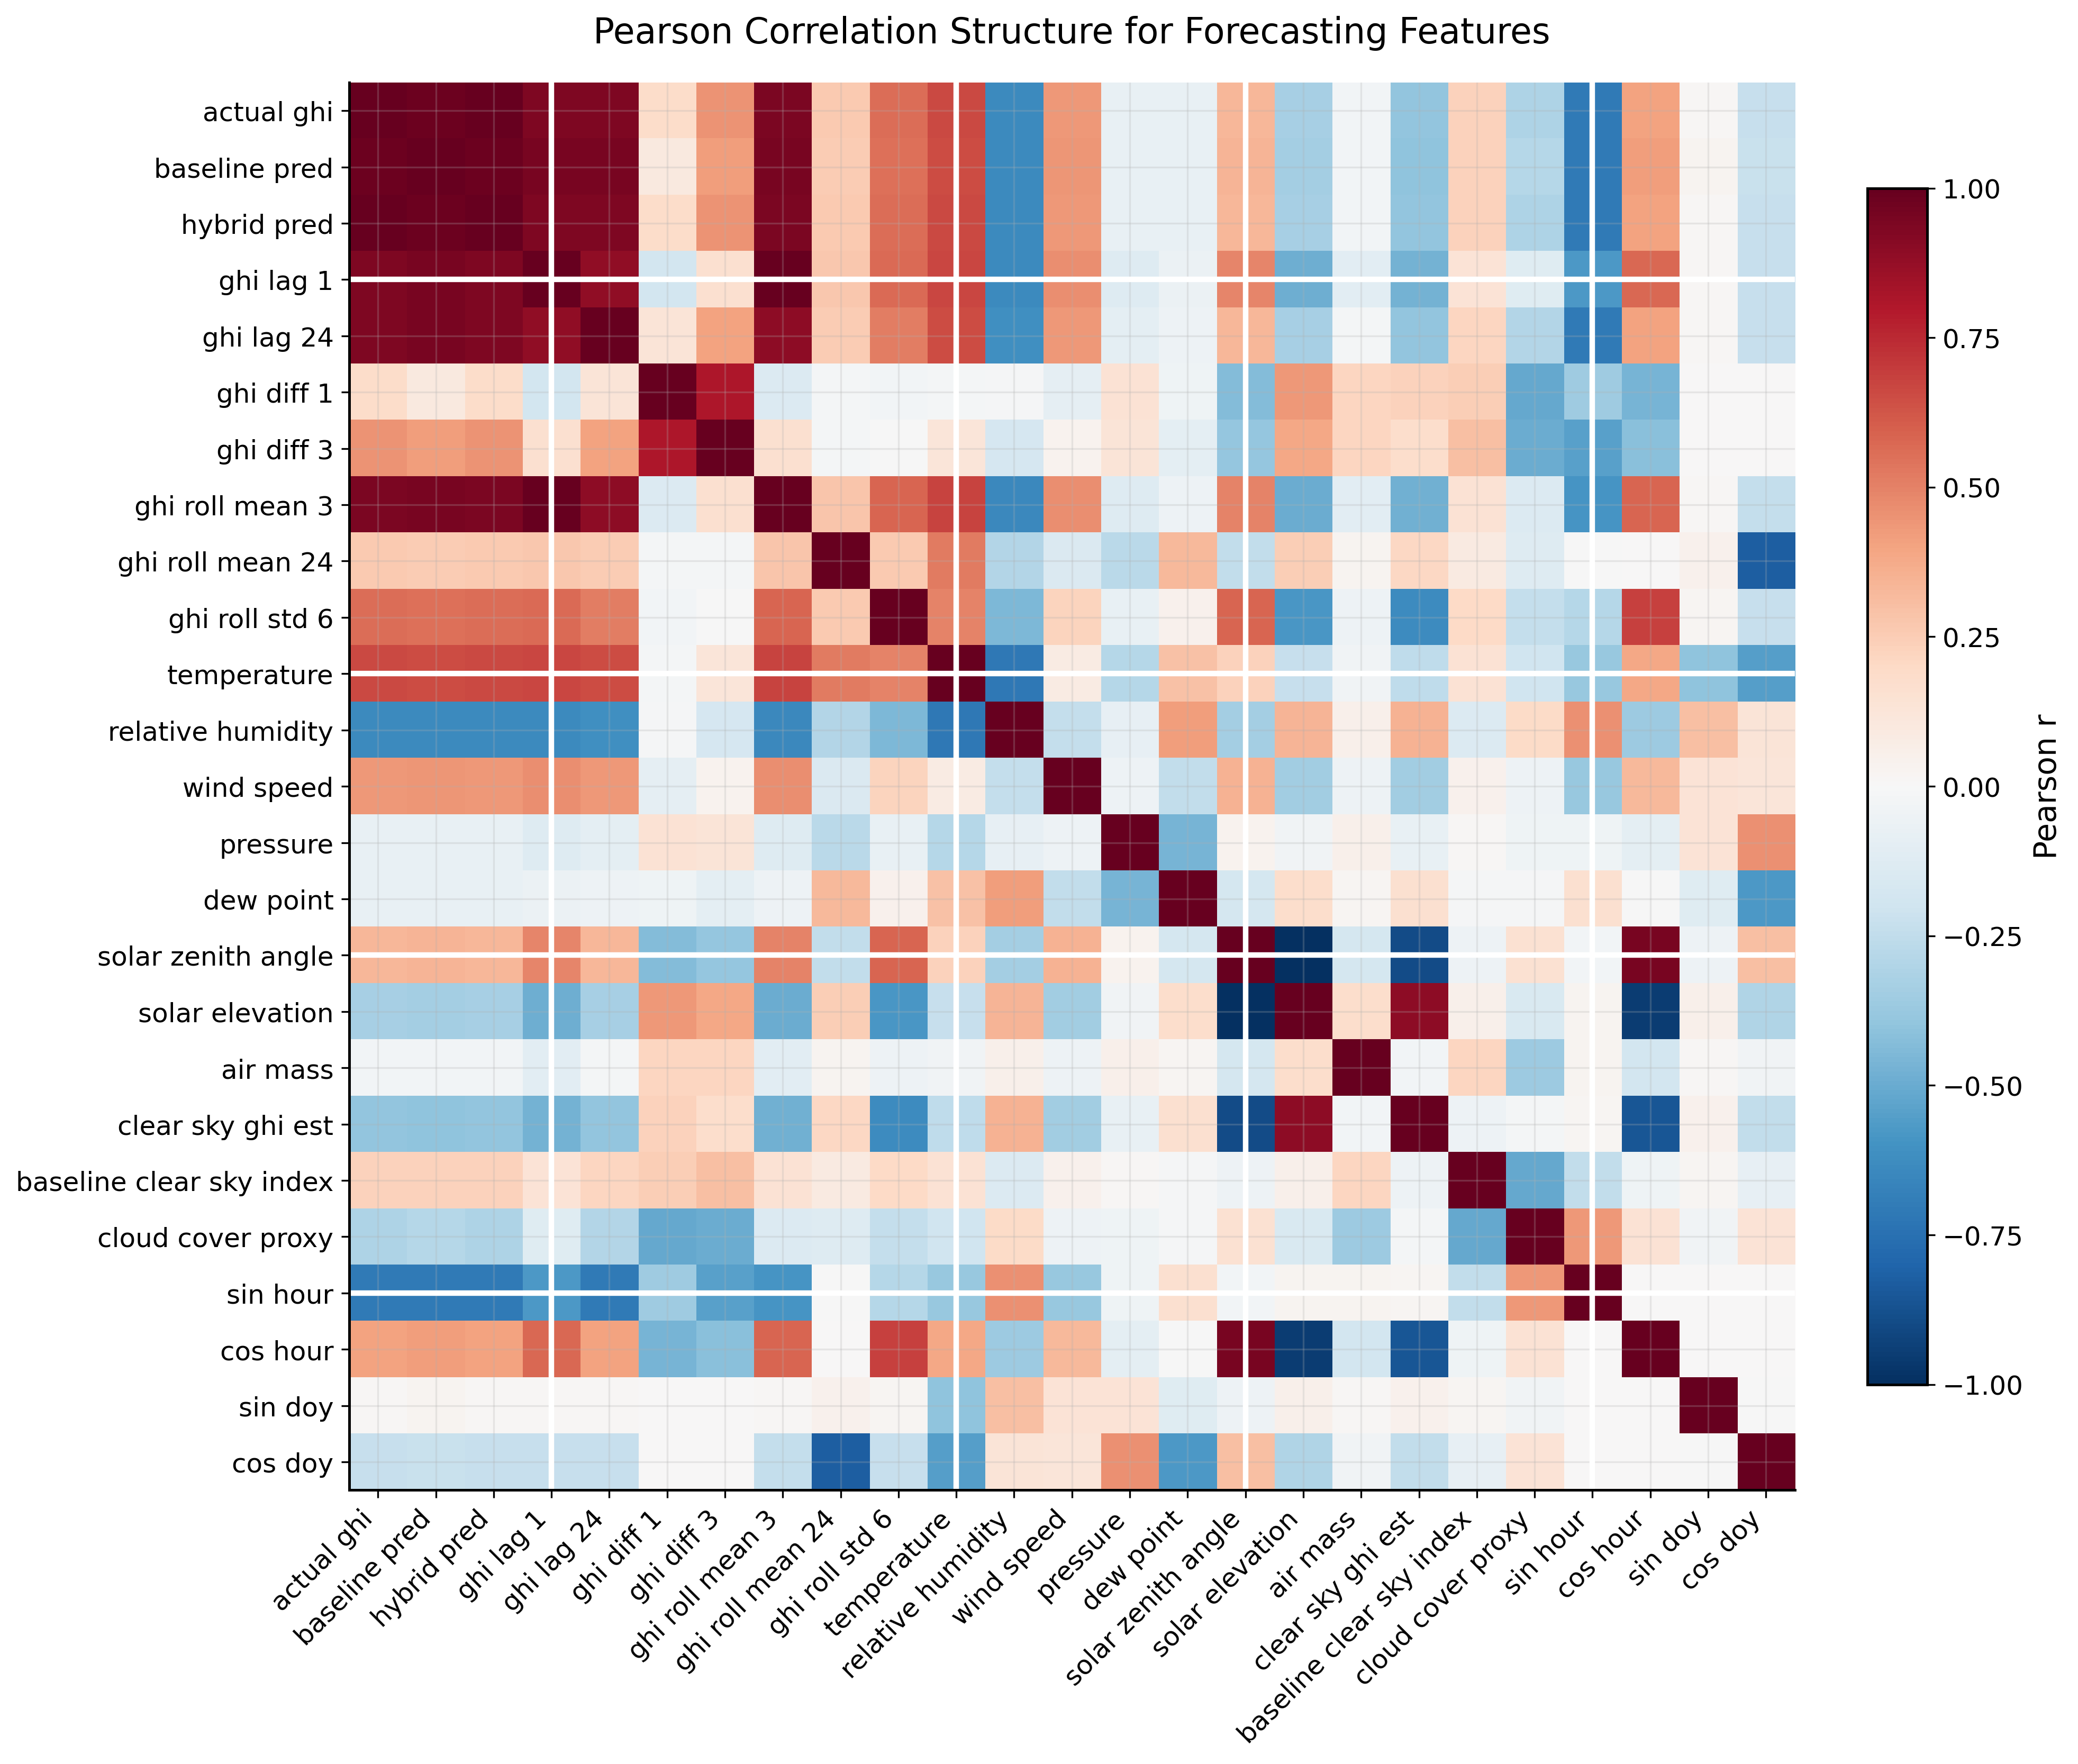

In [64]:
fig1_correlation_heatmap()
img_path = FIGURES_DIR / 'figure_1_correlation_heatmap.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 2. Actual vs predicted comparison

Saved figure_2_actual_vs_predicted
Saved: E:\OE casestudy\code\outputs\figures\figure_2_actual_vs_predicted.png


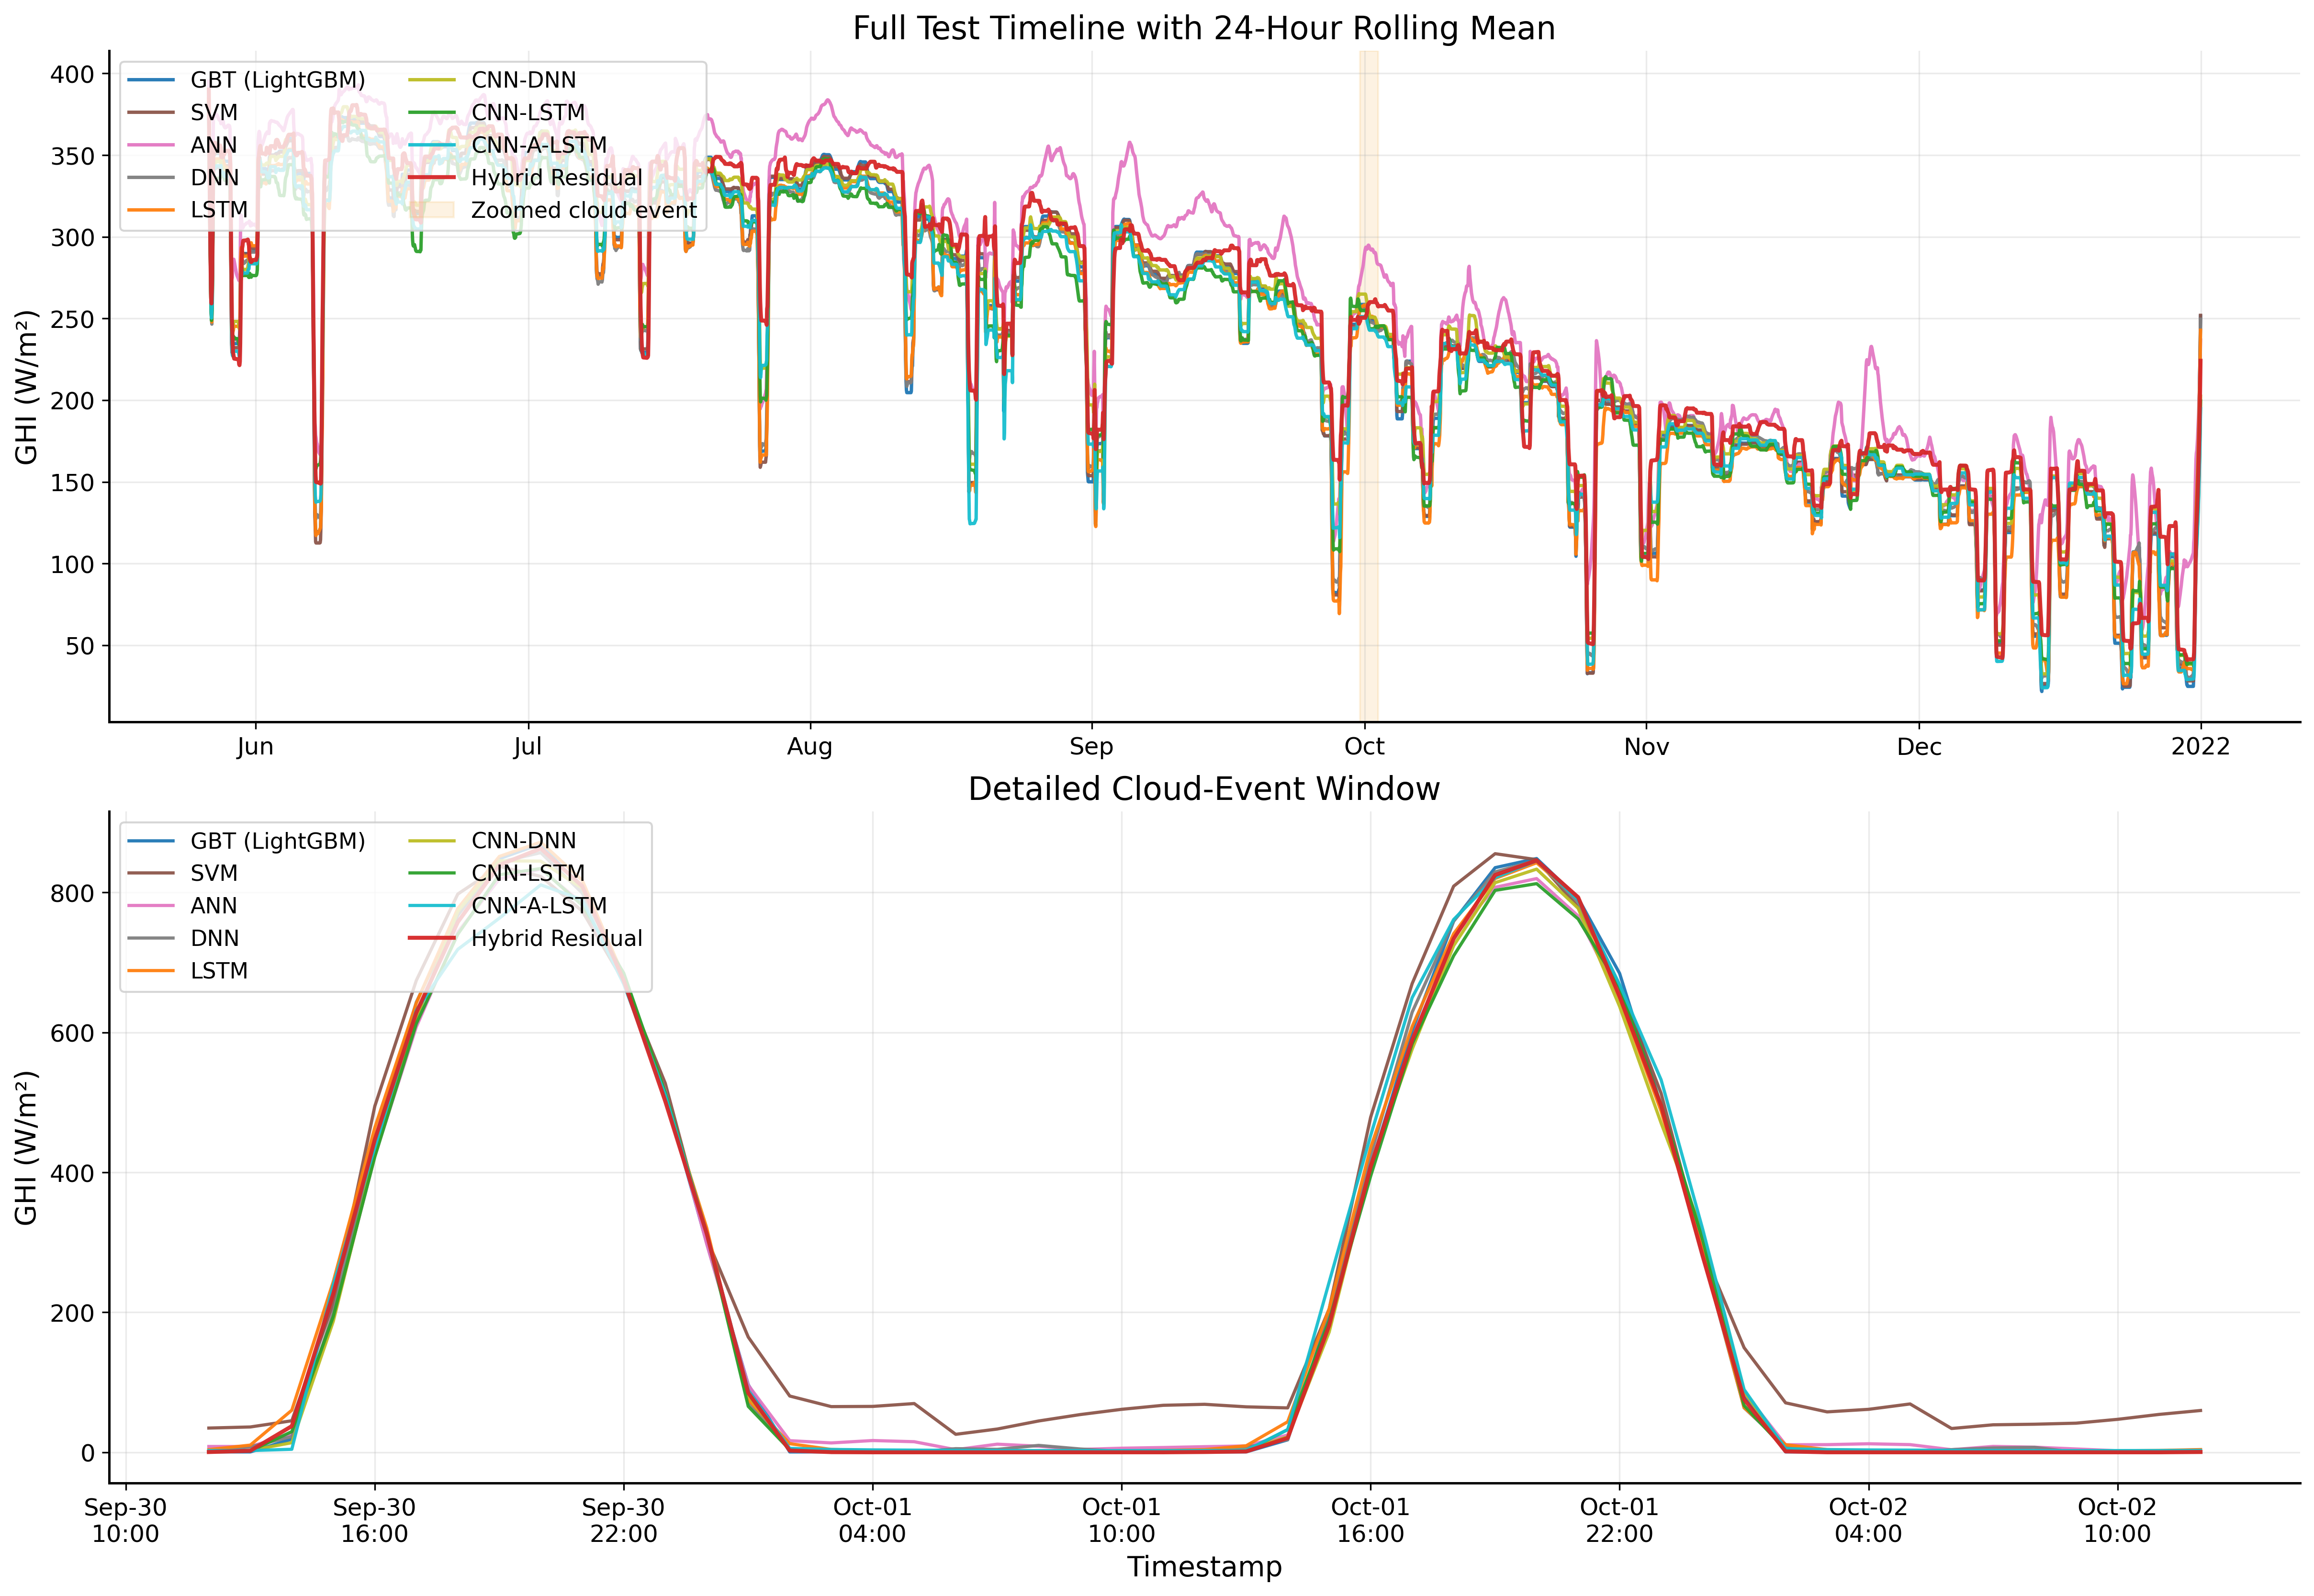

In [65]:
fig2_actual_vs_predicted()
img_path = FIGURES_DIR / 'figure_2_actual_vs_predicted.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 3. Model comparison metrics

Saved figure_3_model_performance_comparison
Saved: E:\OE casestudy\code\outputs\figures\figure_3_model_performance_comparison.png


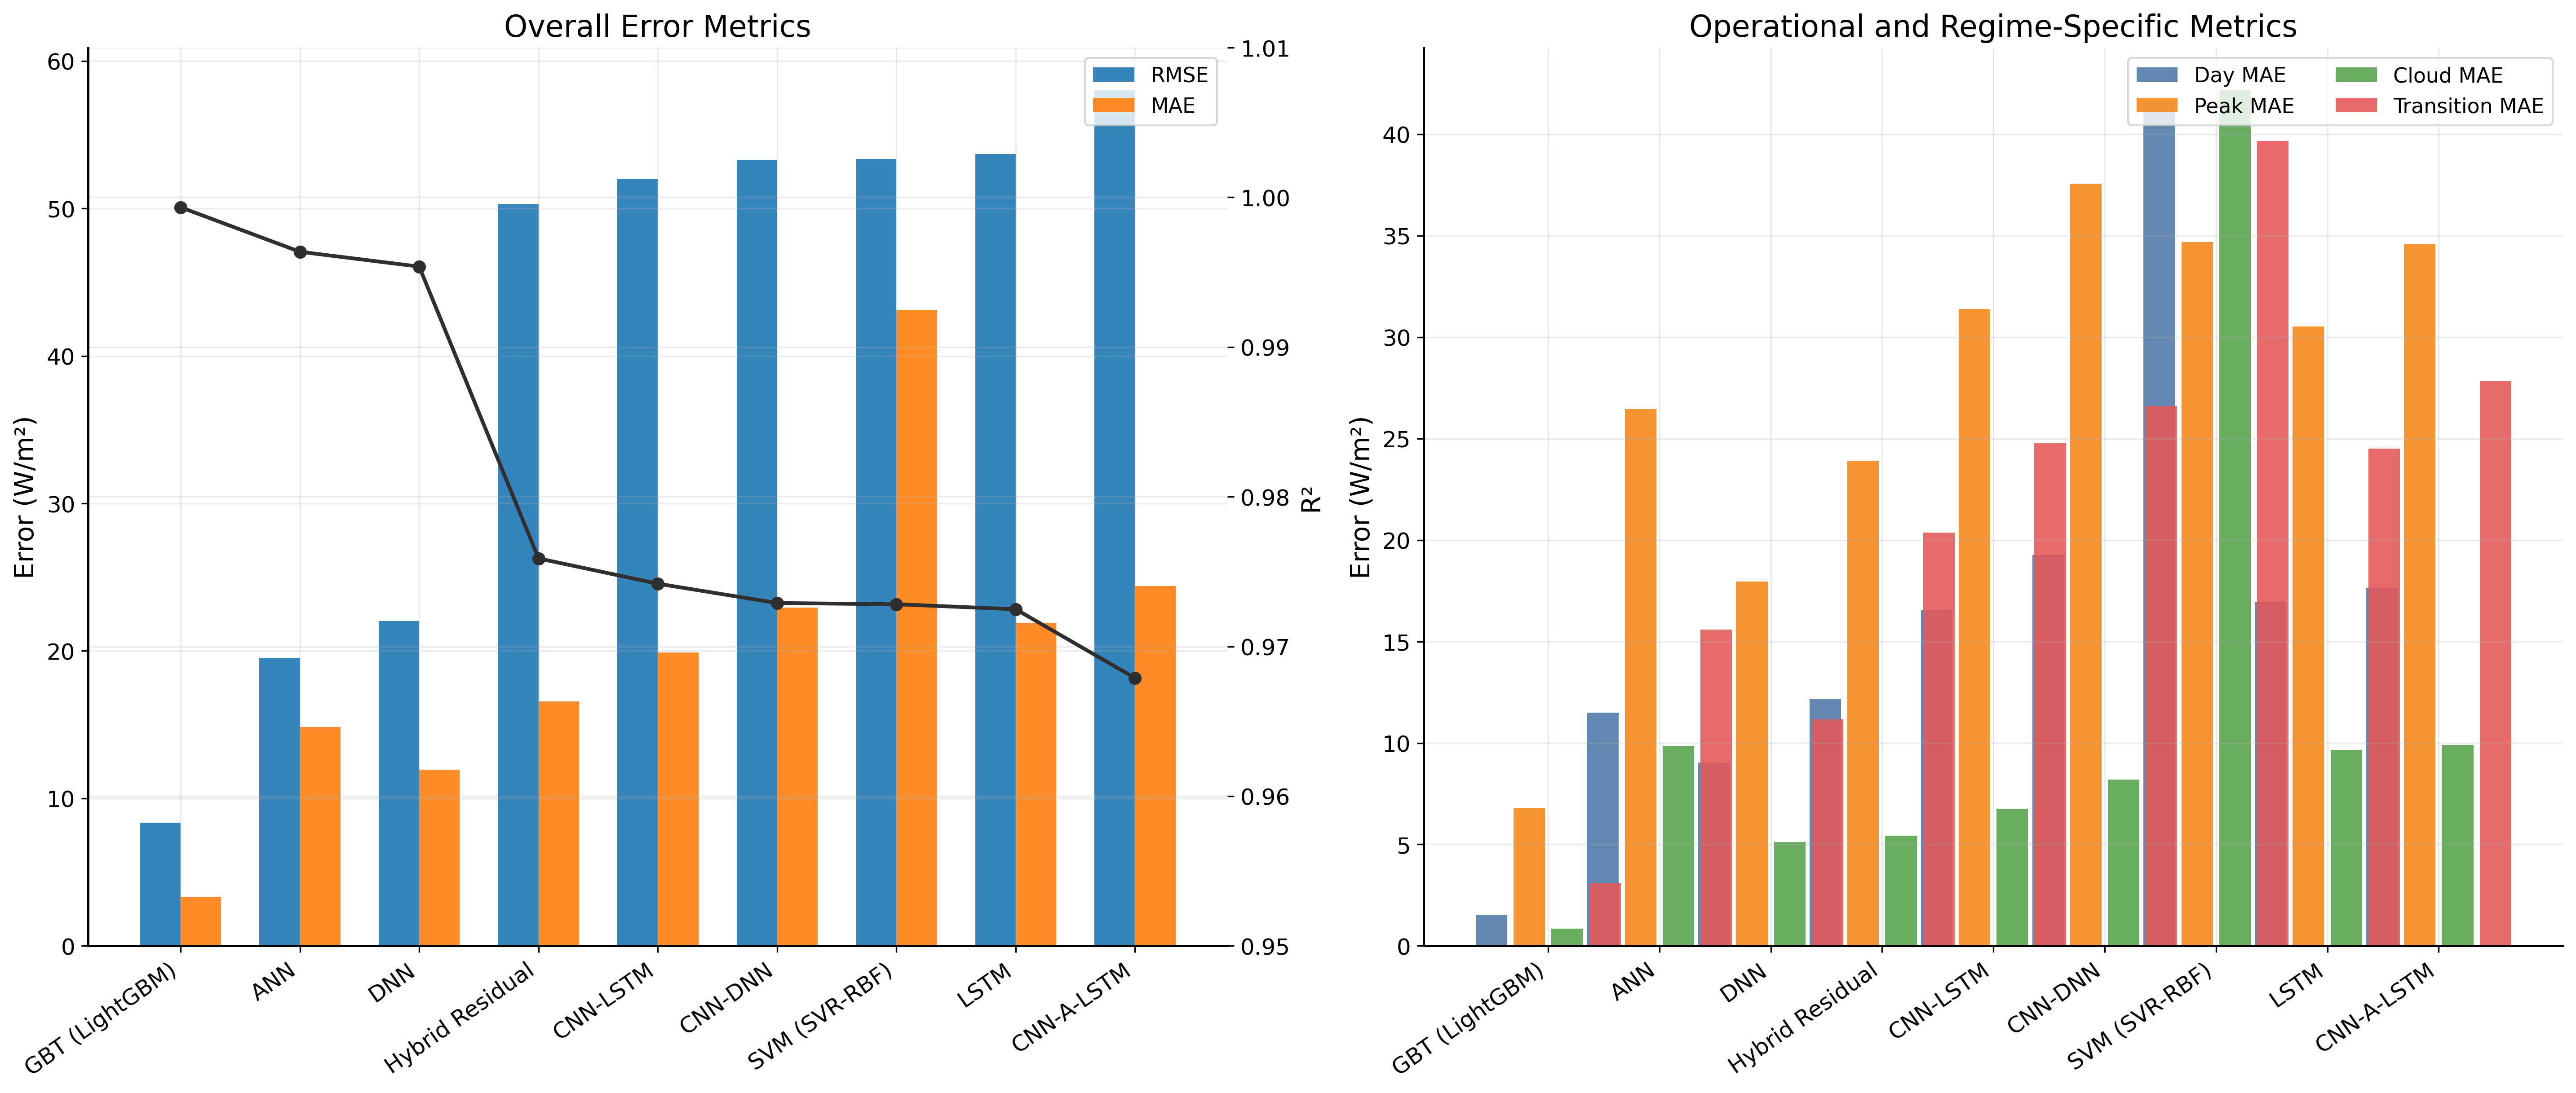

In [66]:
fig3_model_performance()
img_path = FIGURES_DIR / 'figure_3_model_performance_comparison.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 4. Clear sky forecasting results

Saved figure_4_clear_sky_prediction
Saved: E:\OE casestudy\code\outputs\figures\figure_4_clear_sky_prediction.png


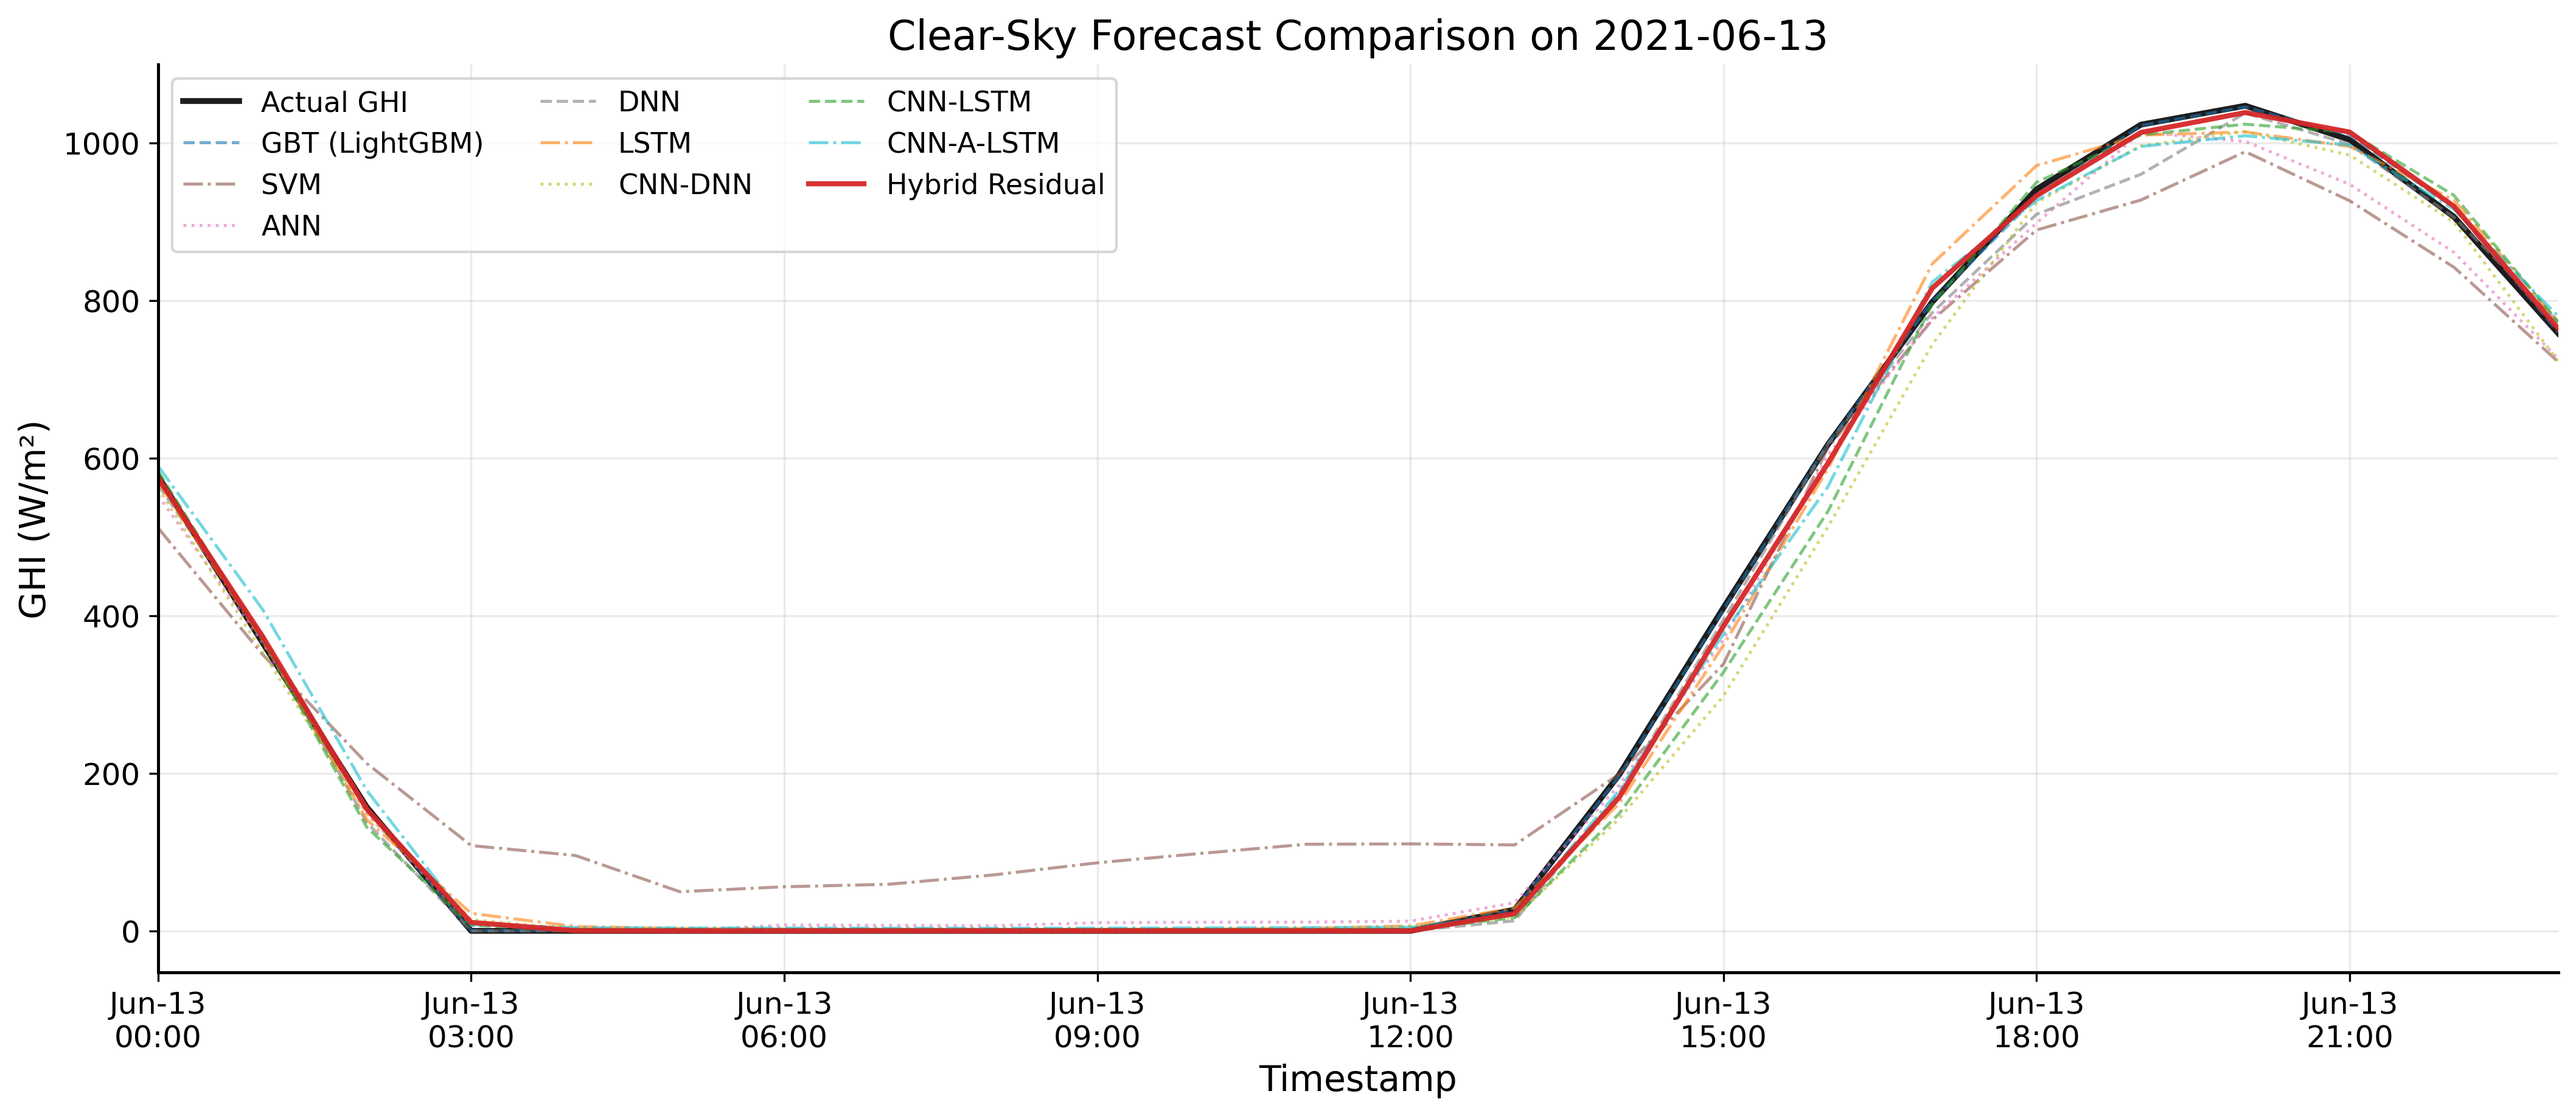

In [67]:
fig4_clear_sky()
img_path = FIGURES_DIR / 'figure_4_clear_sky_prediction.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 5. Cloudy forecasting results

Saved figure_5_cloudy_prediction
Saved: E:\OE casestudy\code\outputs\figures\figure_5_cloudy_prediction.png


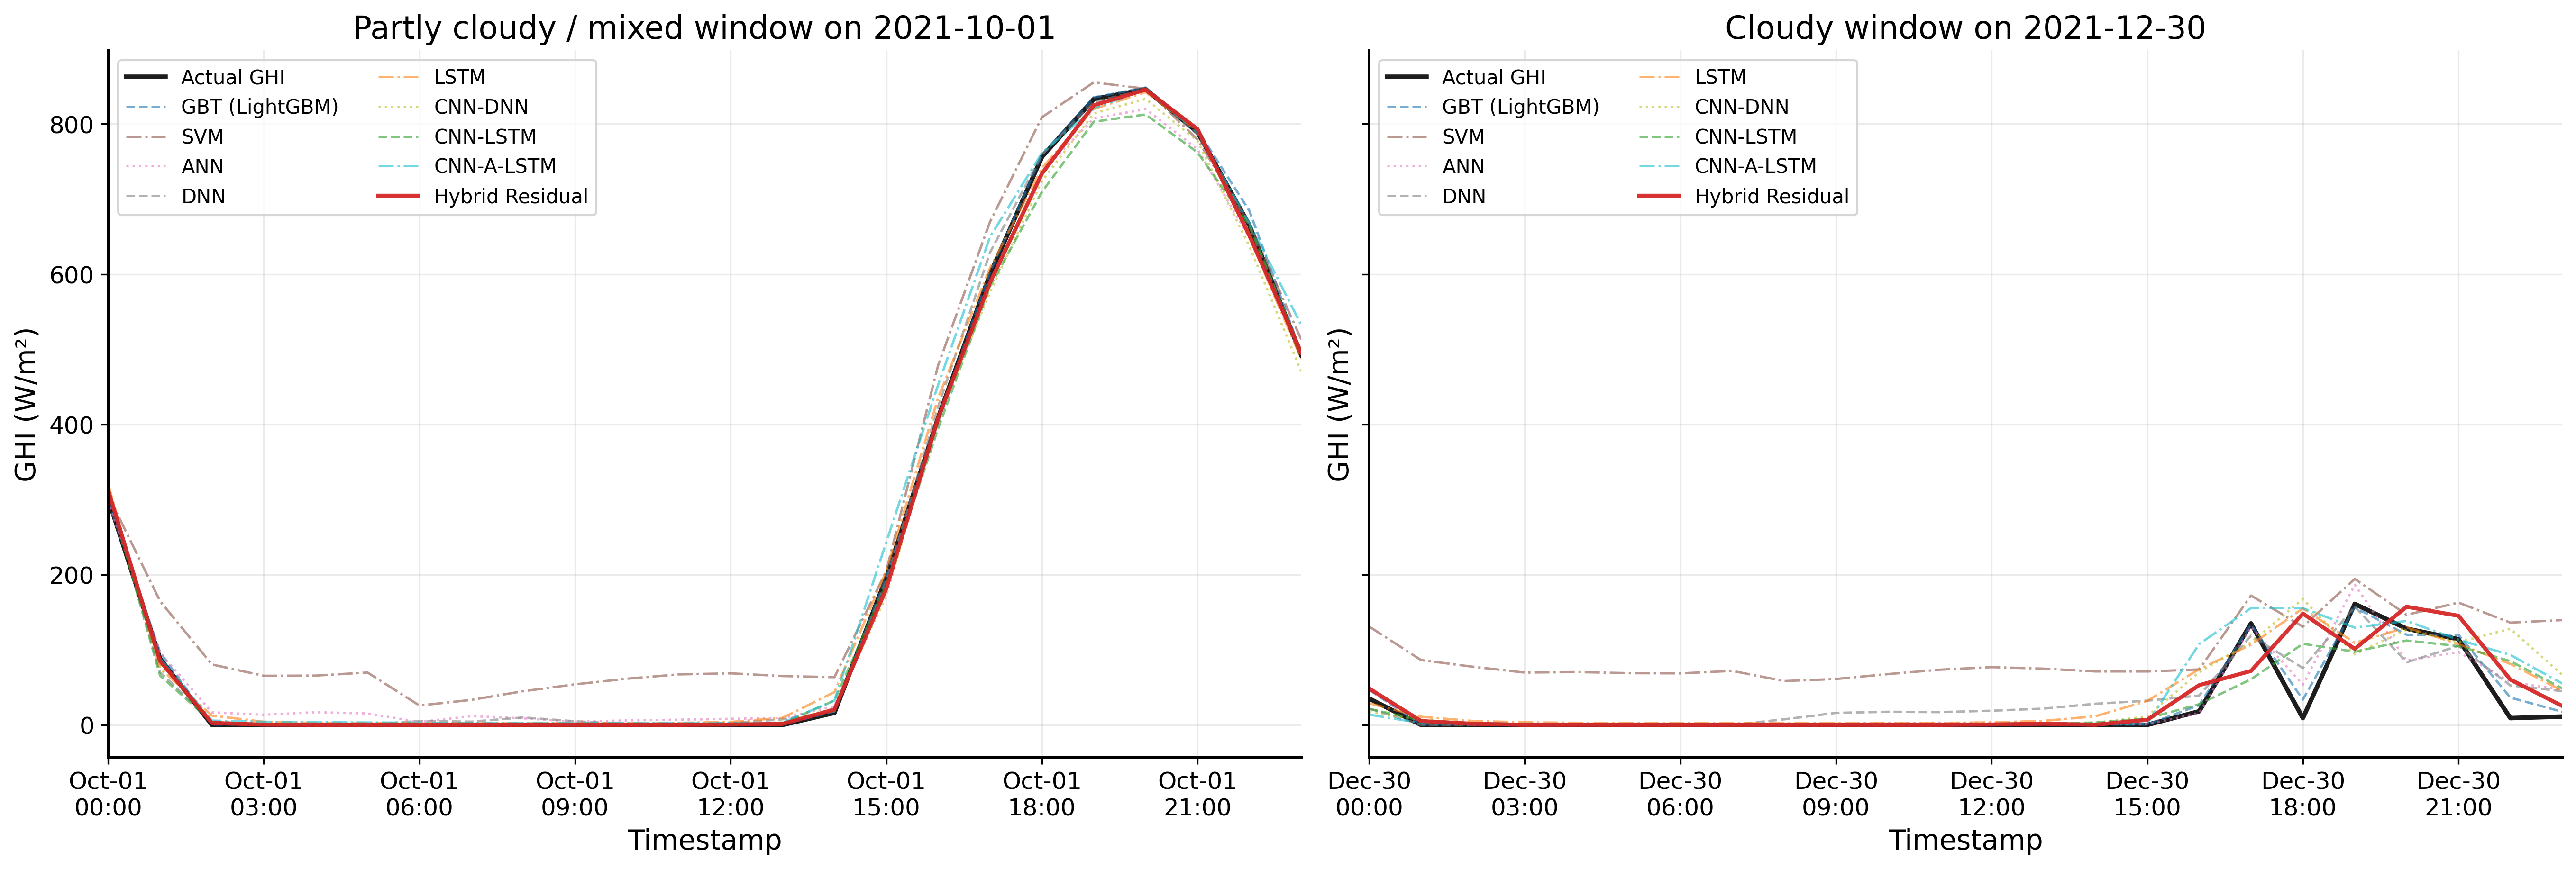

In [68]:
fig5_cloudy_sky()
img_path = FIGURES_DIR / 'figure_5_cloudy_prediction.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 6. Feature importance

Saved figure_6_feature_importance
Saved: E:\OE casestudy\code\outputs\figures\figure_6_feature_importance.png


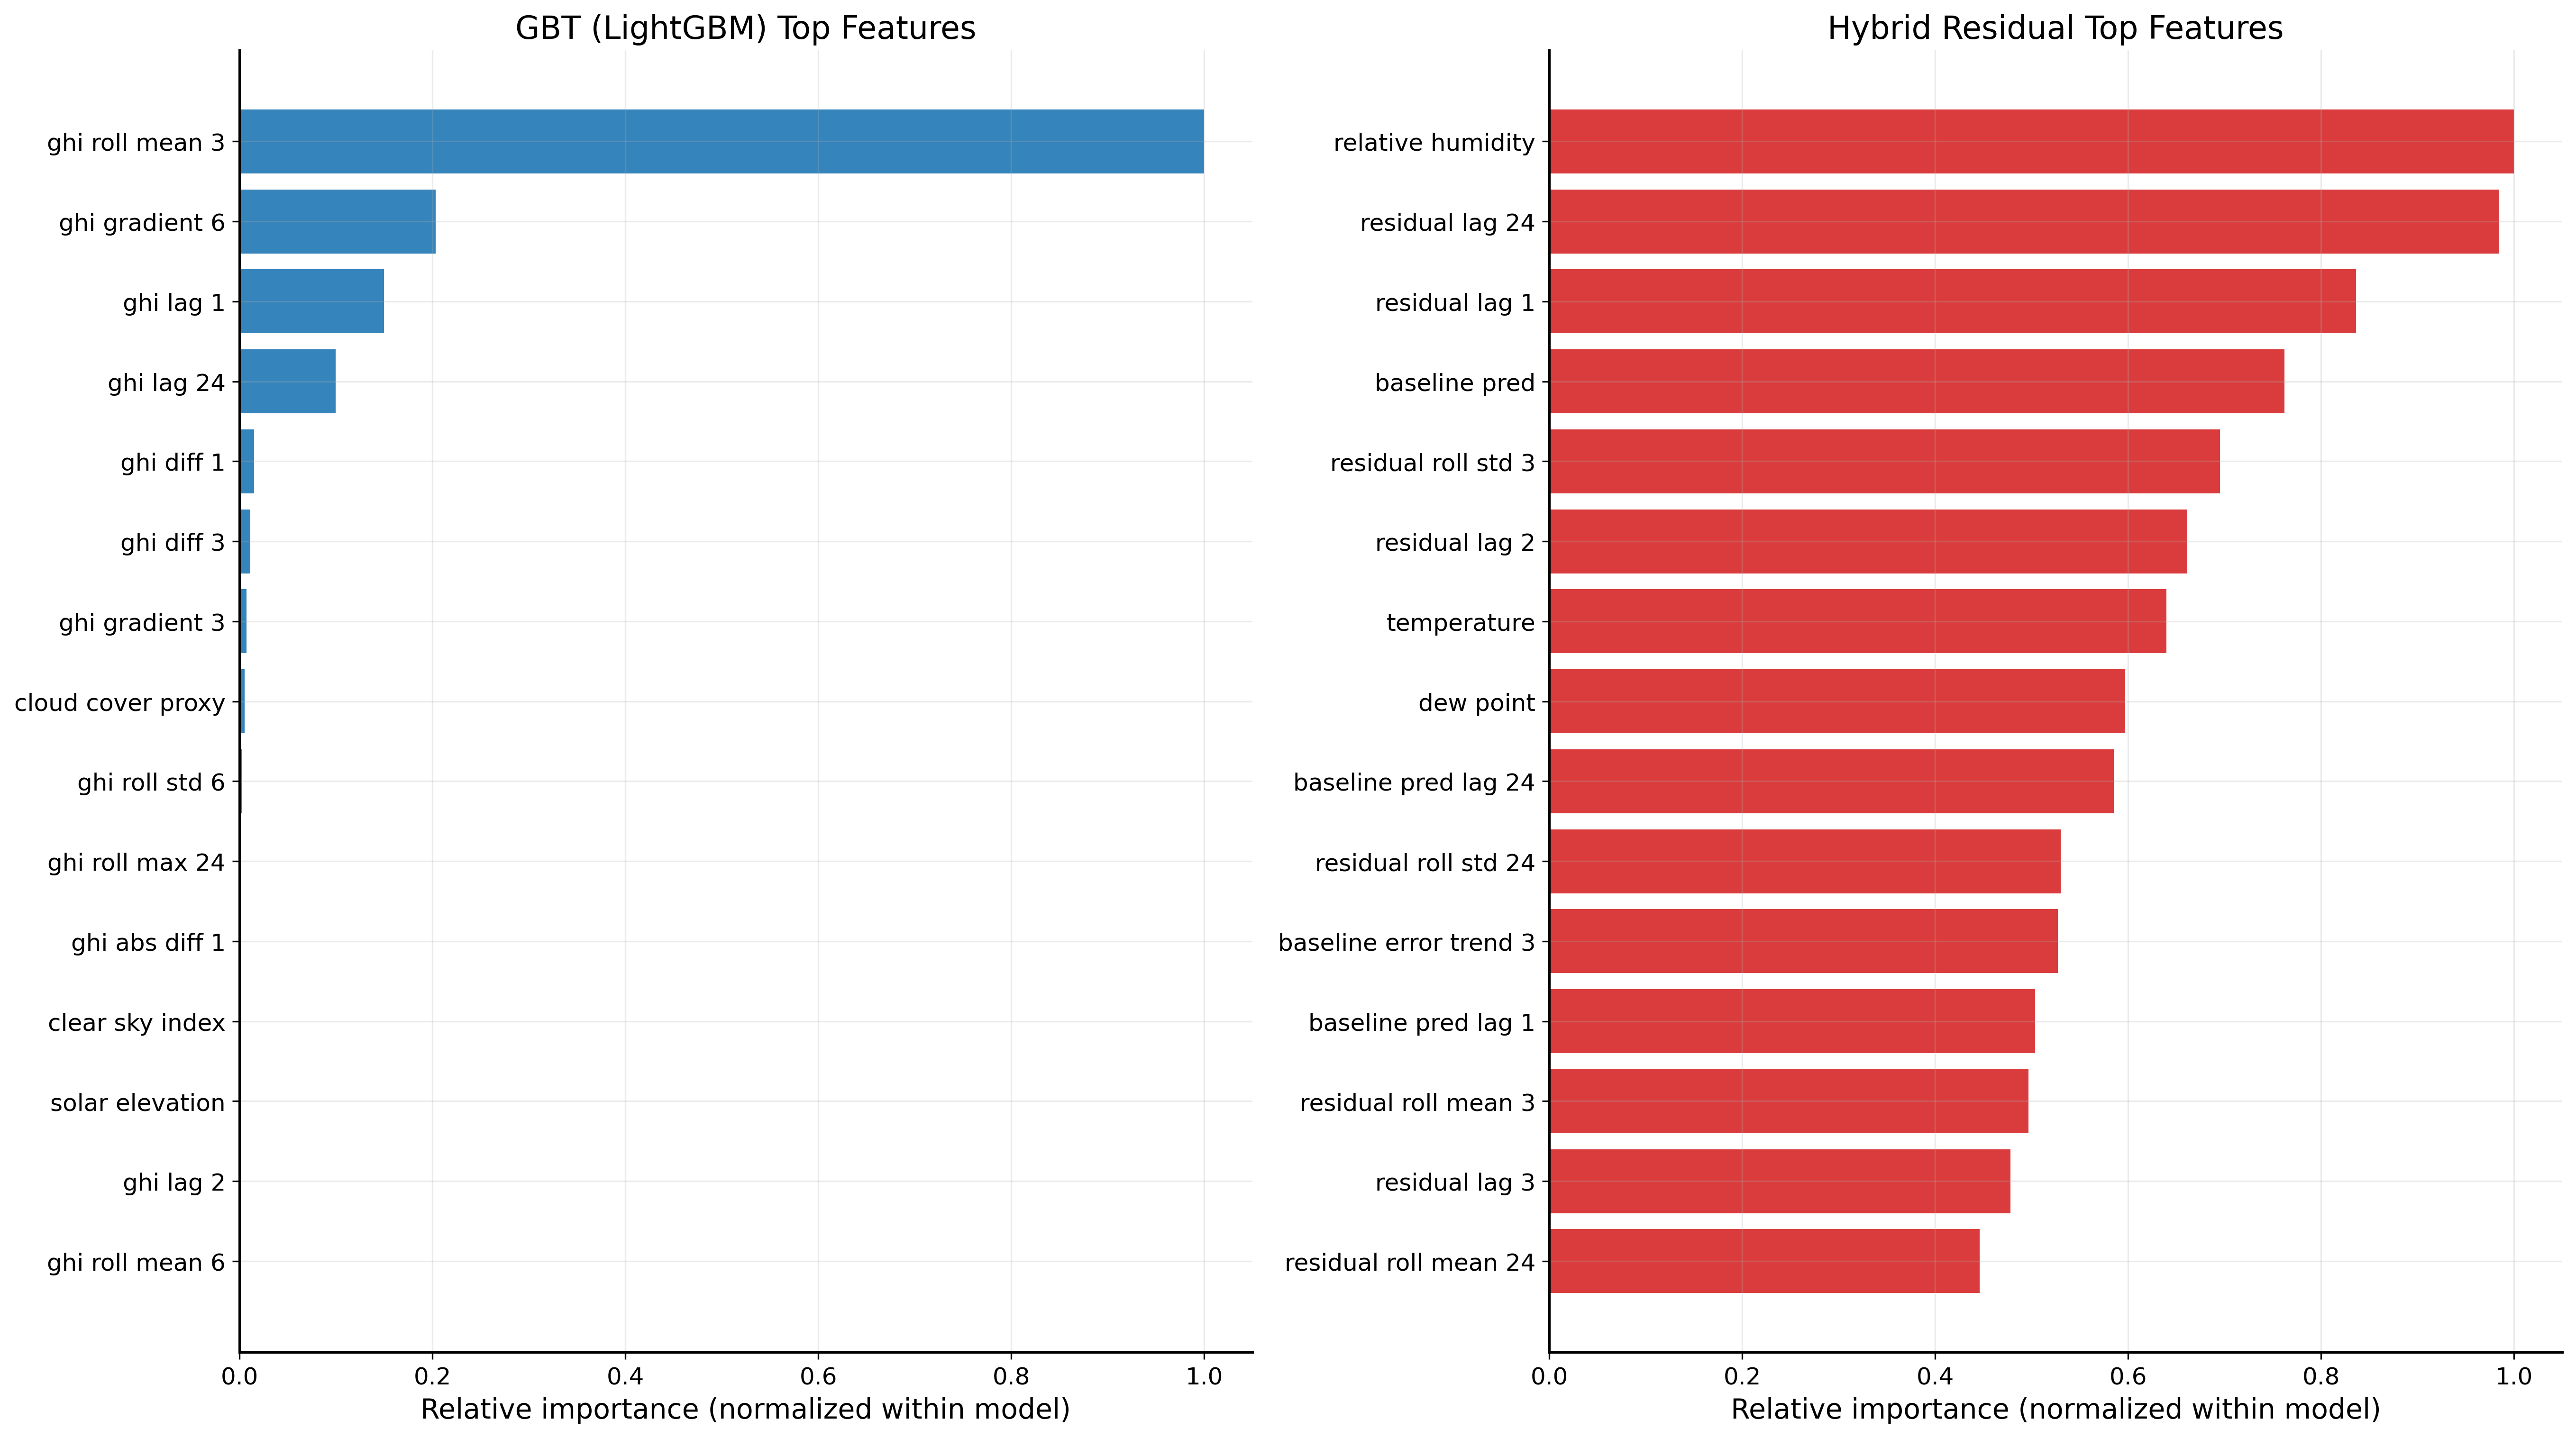

In [69]:
fig6_feature_importance()
img_path = FIGURES_DIR / 'figure_6_feature_importance.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 7. Attention visualization

Saved figure_7_attention_weights
Saved: E:\OE casestudy\code\outputs\figures\figure_7_attention_weights.png


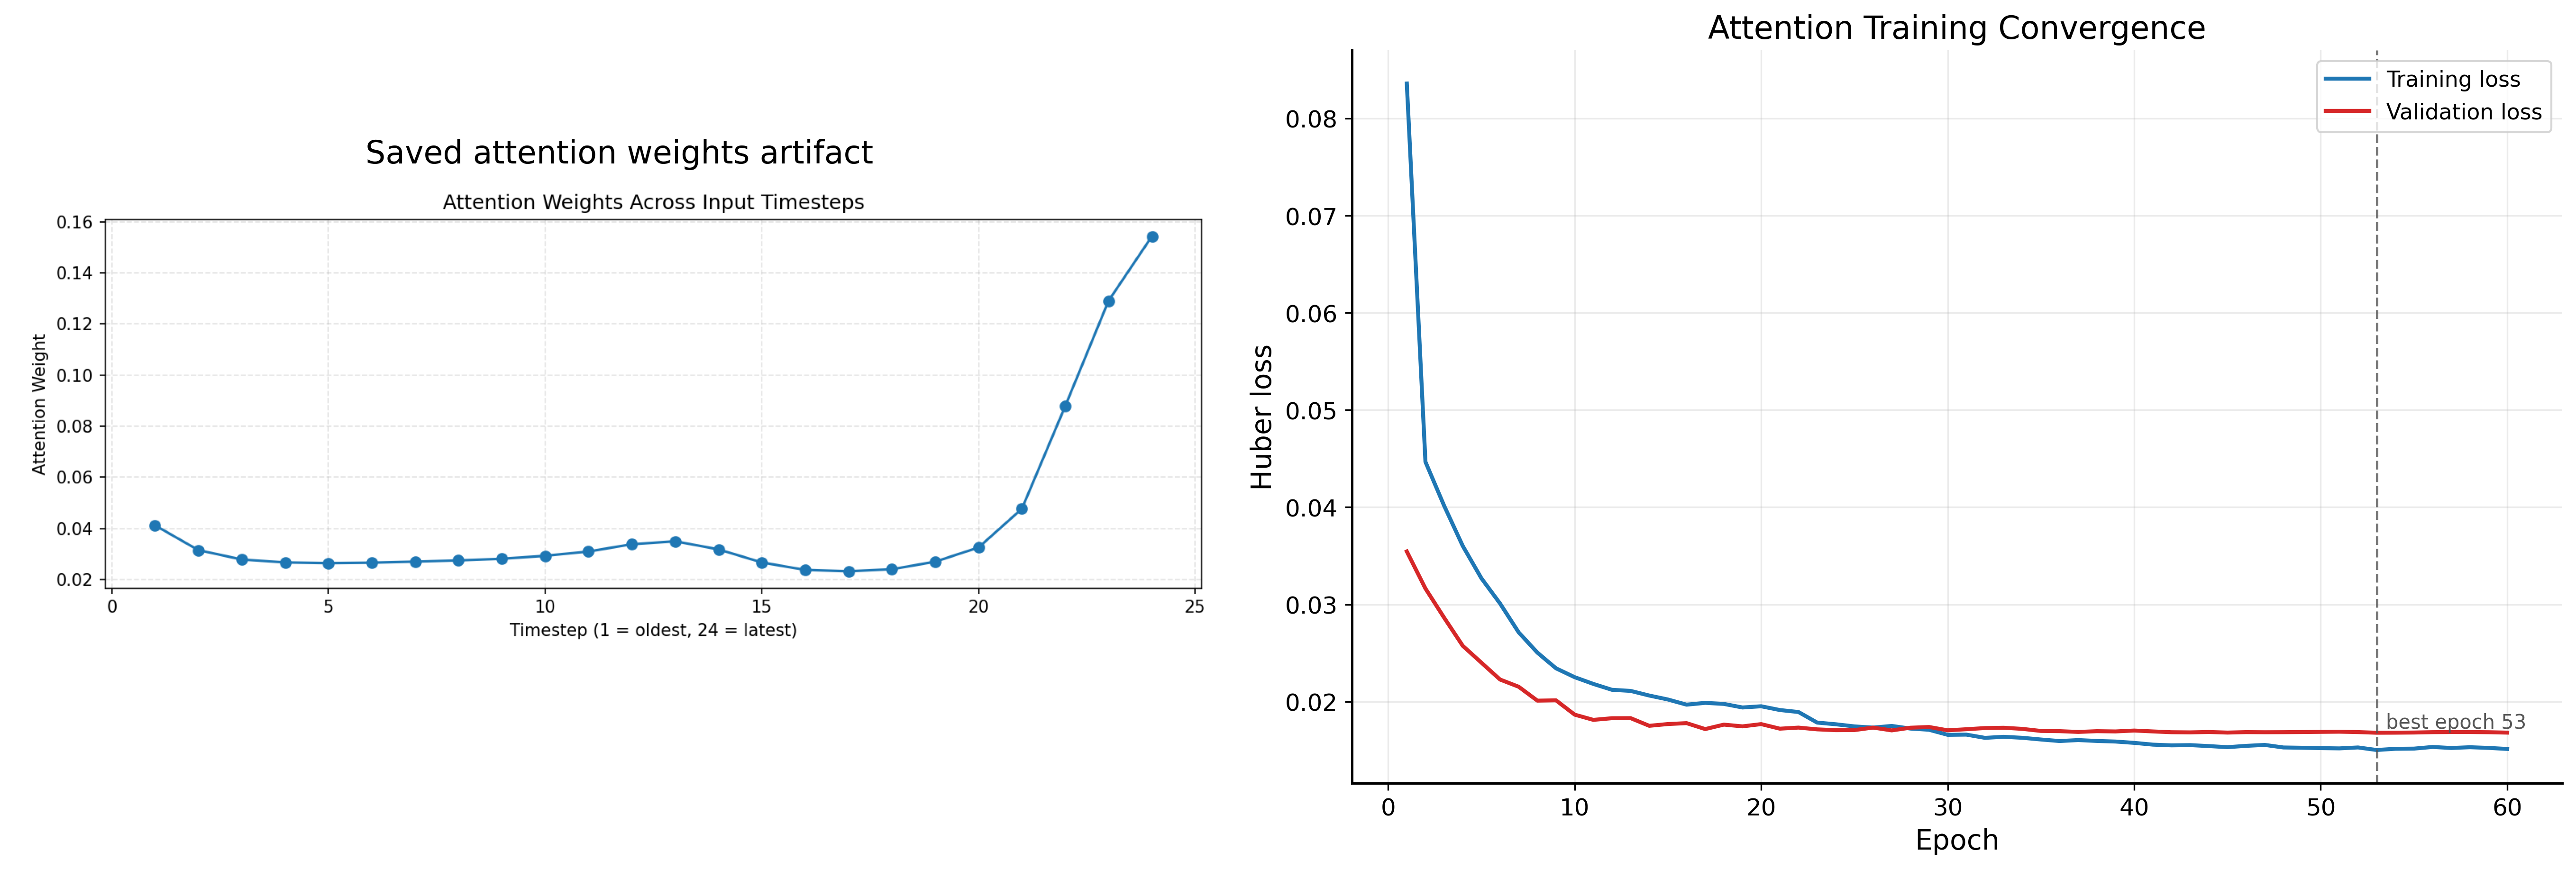

In [70]:
fig7_attention_weights()
img_path = FIGURES_DIR / 'figure_7_attention_weights.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 8. Recursive drift analysis

Saved figure_8_recursive_drift
Saved: E:\OE casestudy\code\outputs\figures\figure_8_recursive_drift.png


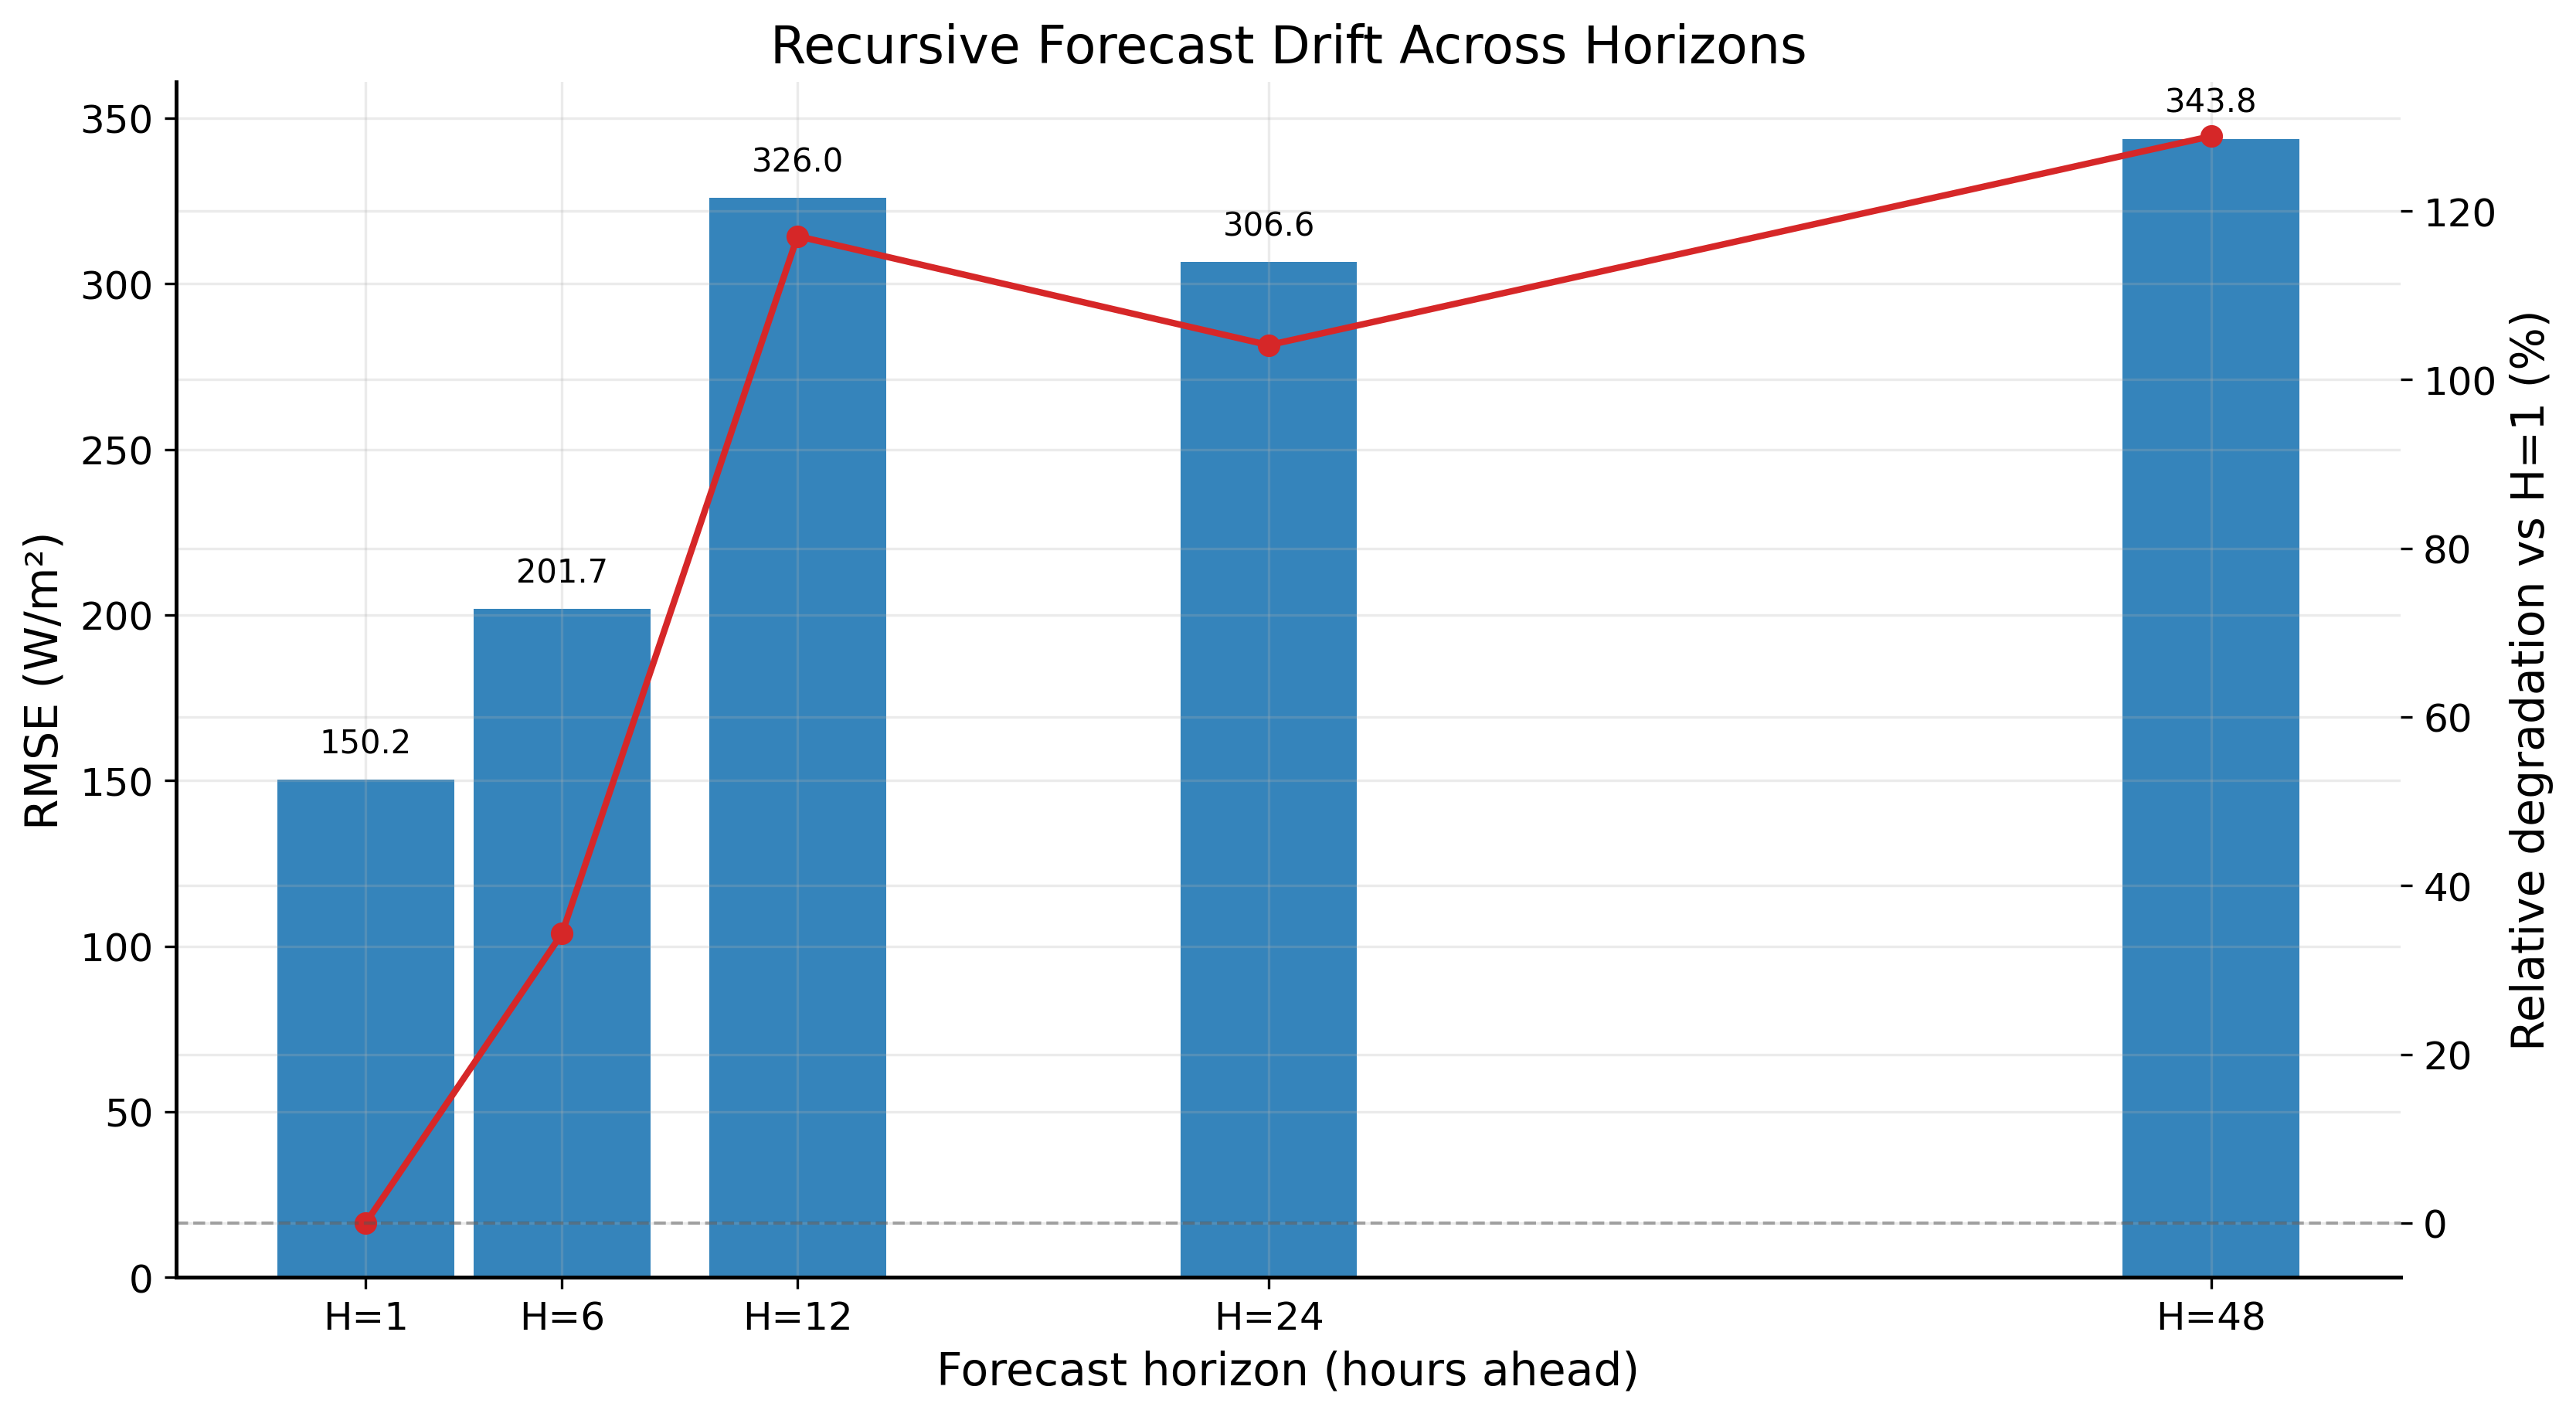

In [71]:
fig8_recursive_drift()
img_path = FIGURES_DIR / 'figure_8_recursive_drift.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 9. Residual distribution

Saved figure_9_residual_distribution
Saved: E:\OE casestudy\code\outputs\figures\figure_9_residual_distribution.png


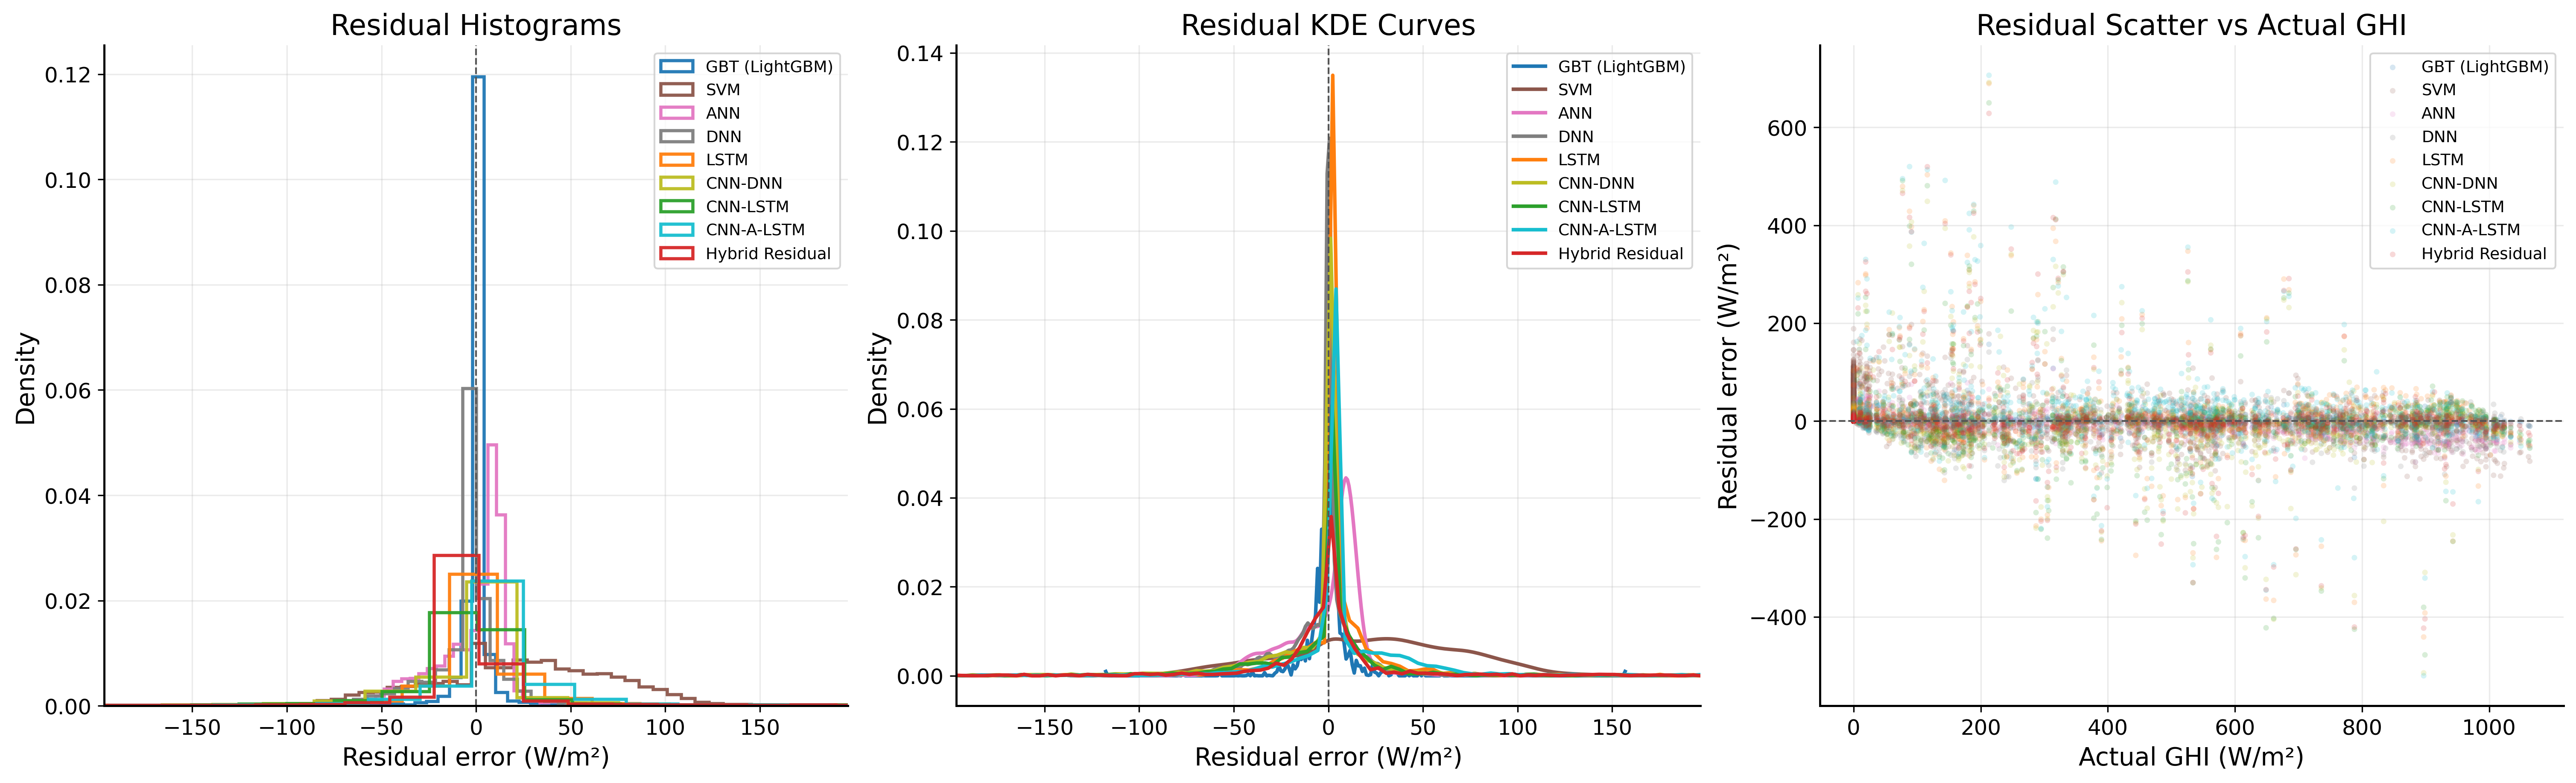

In [72]:
fig9_residual_distribution()
img_path = FIGURES_DIR / 'figure_9_residual_distribution.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 10. Leakage impact comparison

Saved figure_10_leakage_impact
Saved: E:\OE casestudy\code\outputs\figures\figure_10_leakage_impact.png


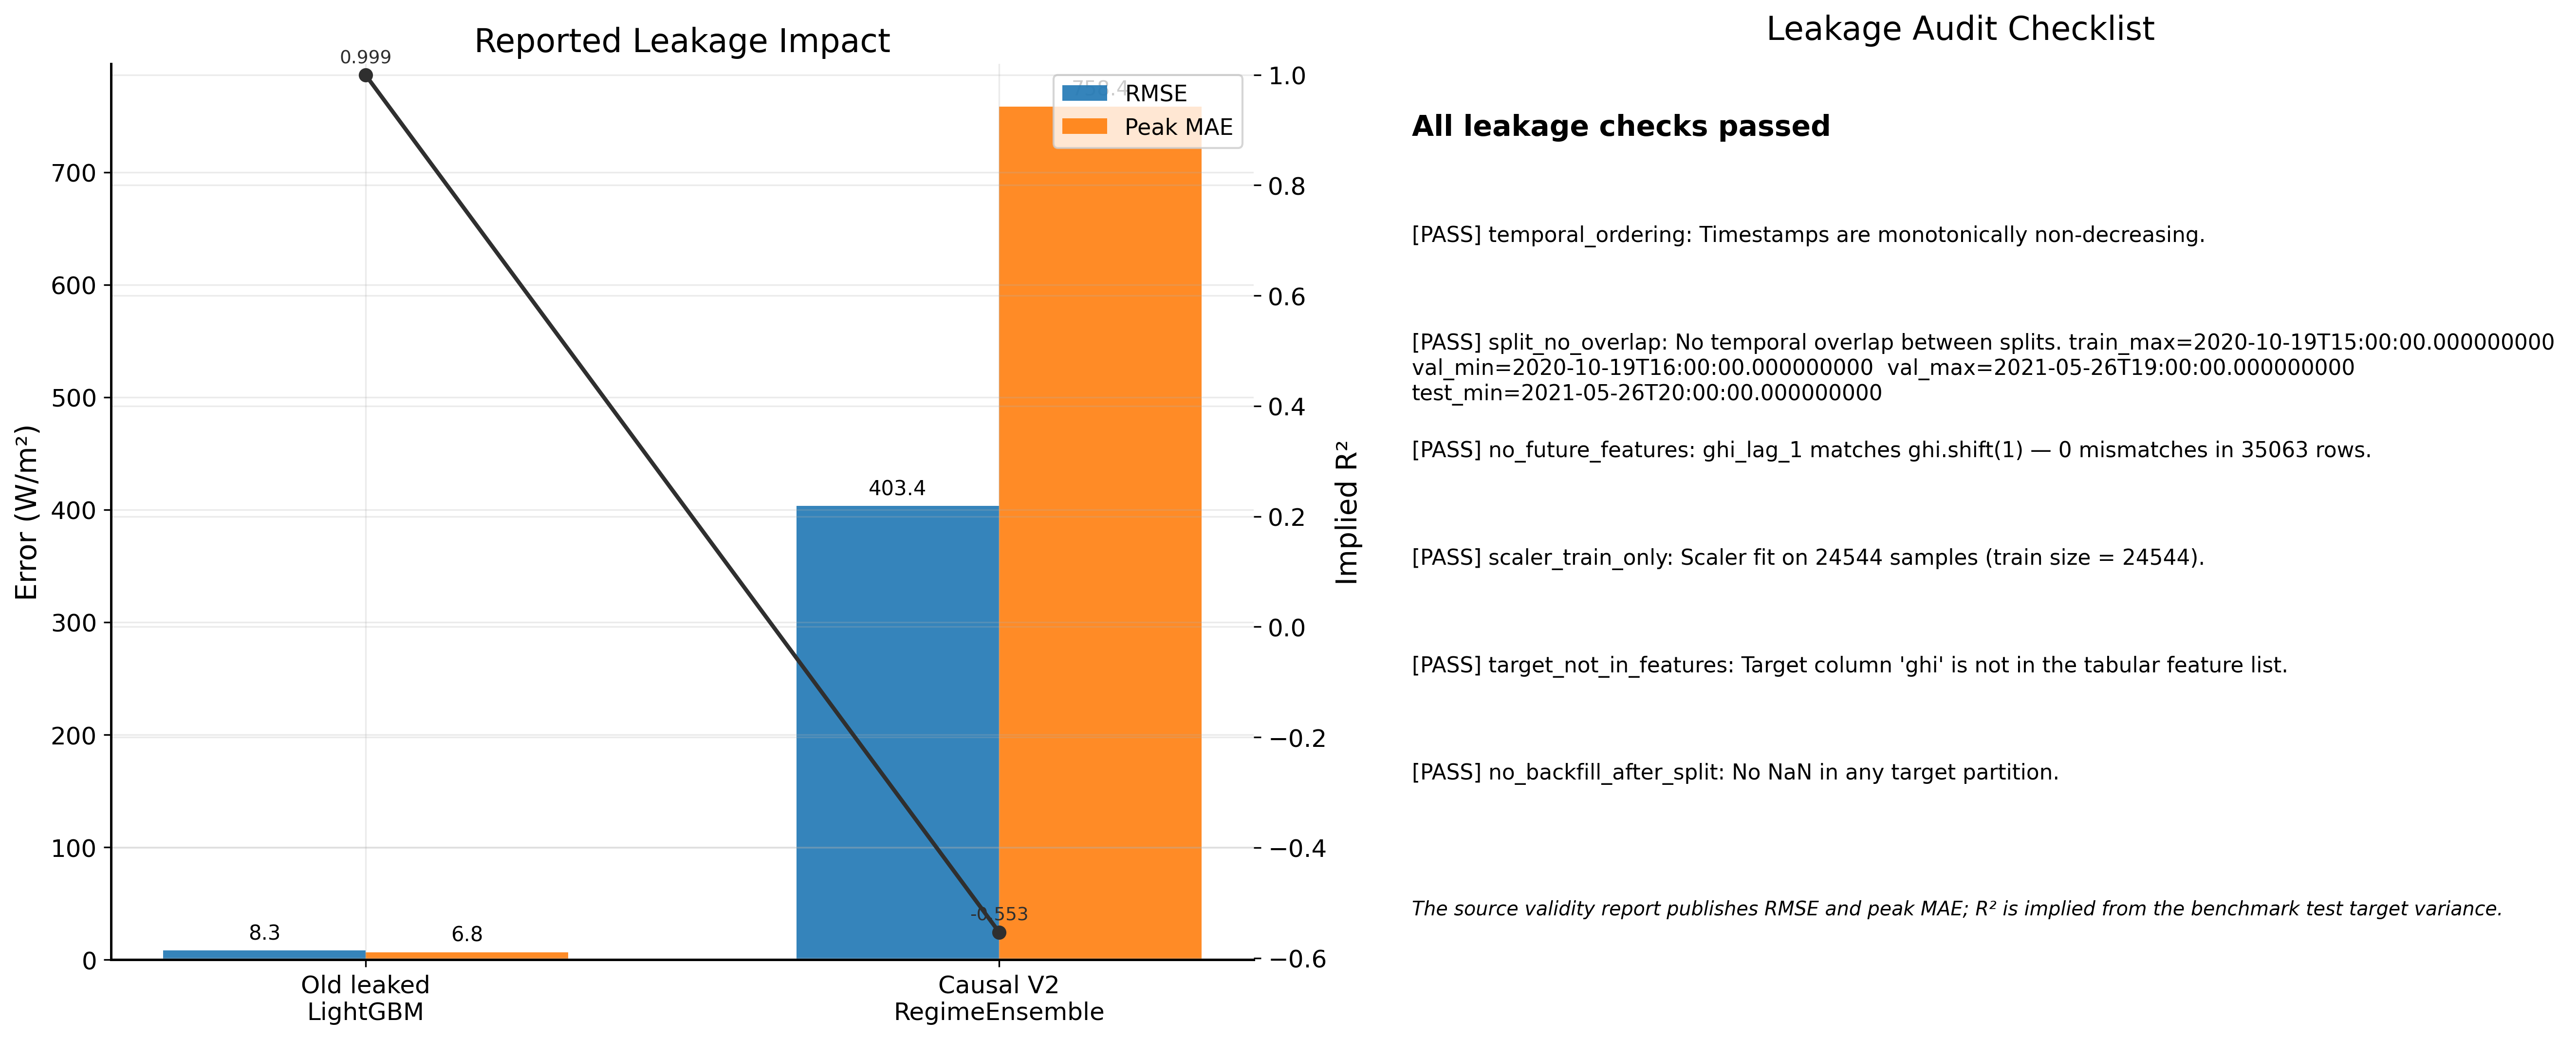

In [73]:
fig10_leakage_impact()
img_path = FIGURES_DIR / 'figure_10_leakage_impact.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


### 11. Regime-wise performance comparison

Saved figure_11_regime_wise_performance
Saved: E:\OE casestudy\code\outputs\figures\figure_11_regime_wise_performance.png


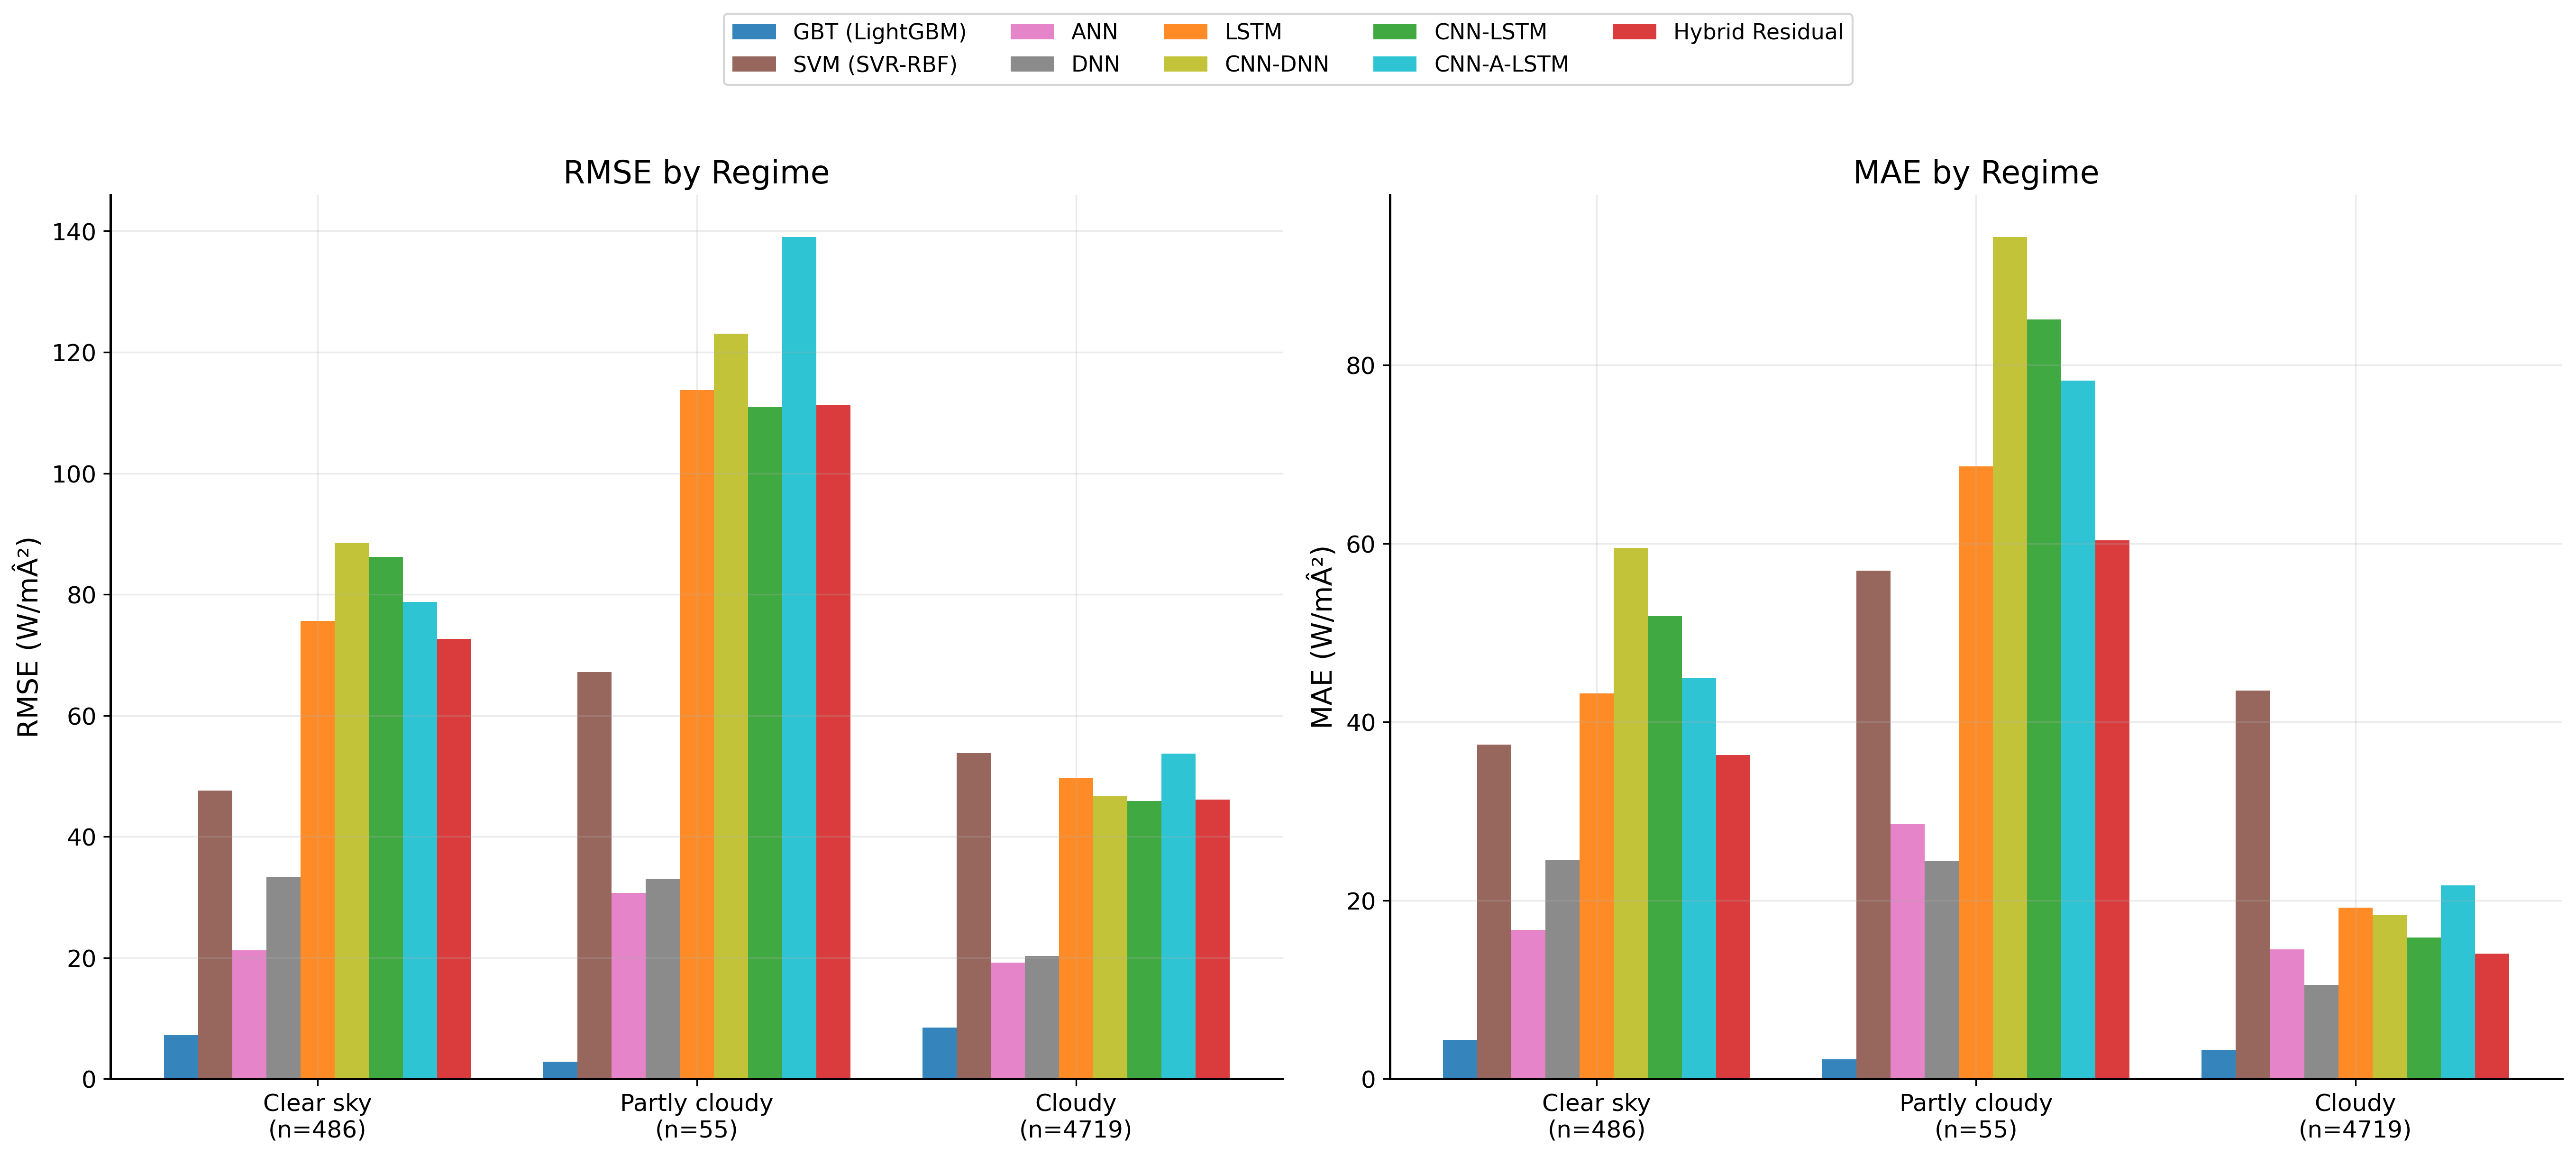

In [74]:
fig11_regime_performance()
img_path = FIGURES_DIR / 'figure_11_regime_wise_performance.png'
print('Saved:', img_path)
display(Image(filename=str(img_path)))


## Section 11 — Final Predictions

In [75]:
from pathlib import Path
import os
import pandas as pd

os.chdir(PROJECT_ROOT)

pred_path = Path(PROJECT_ROOT) / 'outputs' / 'reports' / 'residual_hybrid_predictions.csv'
print('CWD:', Path.cwd())
print('Expecting hybrid predictions at:', pred_path)

if not pred_path.exists():
    reports_dir = Path(PROJECT_ROOT) / 'outputs' / 'reports'
    existing = sorted([p.name for p in reports_dir.glob('*')]) if reports_dir.exists() else []
    raise FileNotFoundError(
        "Hybrid predictions CSV not found: {}\nReports dir contents: {}\nHybrid pipeline likely failed earlier or wrote to a different working directory. Re-run the Hybrid Residual Model cell and ensure it completes without errors.".format(
            pred_path, existing
        )
    )

final_predictions_df = pd.read_csv(pred_path)
final_predictions_df.head(20)


CWD: E:\OE casestudy\code\colab_ready
Expecting hybrid predictions at: E:\OE casestudy\code\colab_ready\outputs\reports\residual_hybrid_predictions.csv


,timestamp,actual_ghi,temperature,relative_humidity,wind_speed,pressure,solar_zenith_angle,hour,sin_hour,cos_hour,...,baseline_error_trend_6,baseline_error_abs_lag_1,baseline_error_abs_roll_24,regime_prob_clear,regime_prob_partly_cloudy,regime_prob_cloudy,regime_label_pred,residual_pred,calibrated_residual,hybrid_pred
0,2018-01-04 00:00:00,65,18.2,32.31,1.0,974,168.713599,0.0,0.000000e+00,1.000000e+00,...,236.311302,116.539665,49.980165,7.698573e-07,1.005031e-06,0.999998,2,2.975394,3.455197,65.638043
1,2018-01-04 01:00:00,0,17.6,34.32,0.8,974,162.284275,1.0,2.588190e-01,9.659258e-01,...,229.715439,2.817154,48.391412,6.379147e-07,8.344037e-07,0.999999,2,-19.370485,-20.046138,0.000000
2,2018-01-04 02:00:00,0,17.4,34.00,0.8,975,150.979313,2.0,5.000000e-01,8.660254e-01,...,201.295414,18.660732,47.991336,7.528541e-07,9.879897e-07,0.999998,2,-6.417352,-6.423227,0.125017
3,2018-01-04 03:00:00,0,17.0,33.49,0.9,975,138.727182,3.0,7.071068e-01,7.071068e-01,...,158.211141,6.548244,47.967037,6.436209e-07,6.788806e-07,0.999999,2,-4.580218,-4.491099,0.000000
4,2018-01-04 04:00:00,0,16.7,32.84,0.9,975,126.323166,4.0,8.660254e-01,5.000000e-01,...,57.092409,3.604810,47.975832,6.436209e-07,6.536925e-07,0.999999,2,-2.170205,-1.956469,0.740643
5,2018-01-04 05:00:00,0,16.4,32.20,0.9,975,114.052340,5.0,9.659258e-01,2.588190e-01,...,-53.098296,2.697112,47.985619,6.436209e-07,6.536925e-07,0.999999,2,-2.135695,-1.920175,0.422081
6,2018-01-04 06:00:00,0,16.1,31.86,1.0,975,102.113774,6.0,1.000000e+00,6.123234e-17,...,-118.881922,2.342256,47.993758,6.436209e-07,6.536954e-07,0.999999,2,-2.224872,-2.013963,0.154202
7,2018-01-04 07:00:00,0,15.9,32.02,1.1,975,90.724807,7.0,9.659258e-01,-2.588190e-01,...,-4.985318,2.168164,48.000229,6.436209e-07,6.536954e-07,0.999999,2,-2.131864,-1.916146,0.173458
8,2018-01-04 08:00:00,0,16.1,32.13,0.9,975,80.176645,8.0,8.660254e-01,-5.000000e-01,...,16.571128,2.089604,48.005697,1.042470e-06,6.885403e-07,0.999998,2,-2.018678,-1.797107,0.272898
9,2018-01-04 09:00:00,0,16.3,32.49,0.6,975,70.885954,9.0,7.071068e-01,-7.071068e-01,...,4.478239,2.070005,48.010696,6.732735e-07,6.783629e-07,0.999999,2,-1.943115,-1.717637,0.346700


In [76]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

EPS = 1e-8

def nrmse(y_true, y_pred, mode="range"):
    """
    Normalized RMSE.
    mode="range"  -> RMSE / (max(y_true) - min(y_true))
    mode="mean"   -> RMSE / mean(y_true)
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    if mode == "mean":
        denom = np.mean(np.abs(y_true))
    else:
        denom = np.max(y_true) - np.min(y_true)

    return float(rmse / (denom + EPS))


def nmae(y_true, y_pred, mode="range"):
    """
    Normalized MAE.
    mode="range"  -> MAE / (max(y_true) - min(y_true))
    mode="mean"   -> MAE / mean(y_true)
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)

    if mode == "mean":
        denom = np.mean(np.abs(y_true))
    else:
        denom = np.max(y_true) - np.min(y_true)

    return float(mae / (denom + EPS))


def evaluate_model(y_true, y_pred, norm_mode="range"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return {
        "nRMSE": nrmse(y_true, y_pred, mode=norm_mode),
        "nMAE": nmae(y_true, y_pred, mode=norm_mode),
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }


def compare_models(y_true, predictions_dict, norm_mode="range", sort_by="nRMSE", save_csv_path=None):
    """
    predictions_dict example:
    {
        "Baseline LSTM": baseline_pred,
        "Attention LSTM": attention_pred,
        "Residual Hybrid": hybrid_pred,
    }
    """
    rows = []
    for model_name, y_pred in predictions_dict.items():
        metrics = evaluate_model(y_true, y_pred, norm_mode=norm_mode)
        rows.append({"Model": model_name, **metrics})

    df = pd.DataFrame(rows)

    # Rank: lower nRMSE/nMAE is better, higher R2 is better
    df = df.sort_values(by=[sort_by, "nMAE", "R2"], ascending=[True, True, False]).reset_index(drop=True)
    df["Rank"] = np.arange(1, len(df) + 1)

    cols = ["Rank", "Model", "nRMSE", "nMAE", "R2", "RMSE", "MAE"]
    df = df[cols]

    if save_csv_path is not None:
        df.to_csv(save_csv_path, index=False)

    return df


# ---------------- Example usage ----------------
# y_true = actual GHI values
# baseline_pred = predictions from model 1
# attention_pred = predictions from model 2
# hybrid_pred = predictions from model 3

# Example:
# models = {
#     "Baseline LSTM": baseline_pred,
#     "Attention LSTM": attention_pred,
#     "Residual Hybrid": hybrid_pred,
# }

# comparison_df = compare_models(
#     y_true=y_true,
#     predictions_dict=models,
#     norm_mode="range",   # change to "mean" if you prefer mean-normalized errors
#     save_csv_path="outputs/reports/model_performance_comparison.csv"
# )

# print(comparison_df.to_string(index=False))

In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Helpers
# -----------------------------
def find_file_anywhere(file_names, roots):
    matches = []
    for root in roots:
        if root.exists():
            for name in file_names:
                matches.extend(root.rglob(name))
    # unique, keep shortest path first
    uniq = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))
    return uniq

def normalize_metrics_df(df):
    rename_map = {
        "model": "Model",
        "r2": "R2",
        "rmse": "RMSE",
        "mae": "MAE",
        "nrmse": "nRMSE",
        "nmae": "nMAE",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    return df

def compute_metrics_from_predictions(pred_df):
    # Try to detect actual column
    actual_candidates = ["actual_ghi", "actual", "y_true", "target", "ghi"]
    actual_col = next((c for c in actual_candidates if c in pred_df.columns), None)
    if actual_col is None:
        raise ValueError(f"Could not find actual column. Found columns: {list(pred_df.columns)[:20]}")

    # Try to detect prediction columns
    preferred_pred_cols = ["baseline_pred", "attention_pred", "hybrid_pred"]
    pred_cols = [c for c in preferred_pred_cols if c in pred_df.columns]

    if not pred_cols:
        pred_cols = [c for c in pred_df.columns if ("pred" in c.lower() or "forecast" in c.lower()) and c != actual_col]

    if not pred_cols:
        raise ValueError(f"Could not find prediction columns. Found columns: {list(pred_df.columns)[:20]}")

    y_true = pred_df[actual_col].to_numpy(dtype=float)
    denom = (np.nanmax(y_true) - np.nanmin(y_true)) + 1e-8

    label_map = {
        "baseline_pred": "Baseline LSTM",
        "attention_pred": "Attention LSTM",
        "hybrid_pred": "Residual Hybrid",
    }

    rows = []
    for col in pred_cols:
        y_pred = pred_df[col].to_numpy(dtype=float)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae = float(mean_absolute_error(y_true, y_pred))
        r2 = float(r2_score(y_true, y_pred))
        rows.append({
            "Model": label_map.get(col, col),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "nRMSE": rmse / denom,
            "nMAE": mae / denom,
        })

    out = pd.DataFrame(rows).sort_values(["nRMSE", "nMAE", "R2"], ascending=[True, True, False]).reset_index(drop=True)
    out.insert(0, "Rank", np.arange(1, len(out) + 1))
    return out

# -----------------------------
# 1) Find files
# -----------------------------
metric_names = [
    "model_performance_comparison.csv",
    "model_forecast_comparison_metrics.csv",
]
pred_names = [
    "model_forecast_comparison_predictions.csv",
]

roots = [
    Path.cwd(),
    Path("/content"),
    Path("/mnt/data"),
    Path("/kaggle/input"),
]

metric_matches = find_file_anywhere(metric_names, roots)
pred_matches = find_file_anywhere(pred_names, roots)

df = None

# -----------------------------
# 2) Load metric file if found
# -----------------------------
if metric_matches:
    chosen = metric_matches[0]
    print(f"Loaded metrics: {chosen}")
    df = pd.read_csv(chosen)
    df = normalize_metrics_df(df)

# -----------------------------
# 3) Else build from prediction file
# -----------------------------
elif pred_matches:
    chosen = pred_matches[0]
    print(f"Loaded predictions: {chosen}")
    pred_df = pd.read_csv(chosen)
    df = compute_metrics_from_predictions(pred_df)

# -----------------------------
# 4) Else ask for upload (Colab)
# -----------------------------
else:
    print("No matching CSV found in current runtime. Trying upload flow...")
    try:
        from google.colab import files
        uploaded = files.upload()  # choose your CSV from local machine
        if not uploaded:
            raise FileNotFoundError("No file uploaded.")
        uploaded_name = next(iter(uploaded.keys()))
        up_path = Path(uploaded_name)
        print(f"Uploaded: {up_path}")

        temp_df = pd.read_csv(up_path)

        # If uploaded file is already metrics
        temp_norm = normalize_metrics_df(temp_df.copy())
        if {"Model", "R2"}.issubset(temp_norm.columns):
            if "nRMSE" not in temp_norm.columns or "nMAE" not in temp_norm.columns:
                # Need predictions for normalization; fallback: compute from RMSE/MAE using RMSE max-min approx not possible.
                # Keep existing values if no normalized metrics available.
                print("Uploaded metrics file has no nRMSE/nMAE; plotting available columns.")
            df = temp_norm
        else:
            # Treat as predictions
            df = compute_metrics_from_predictions(temp_df)

    except Exception as e:
        raise FileNotFoundError(
            f"Could not find or upload required CSV.\n"
            f"Working directory: {Path.cwd()}\n"
            f"Error: {e}\n"
            f"Please upload one of these files:\n"
            f"- model_performance_comparison.csv\n"
            f"- model_forecast_comparison_metrics.csv\n"
            f"- model_forecast_comparison_predictions.csv"
        )

# -----------------------------
# 5) Final checks and plotting
# -----------------------------
required_core = {"Model", "R2"}
if not required_core.issubset(df.columns):
    raise ValueError(f"Missing required columns for plotting. Found: {list(df.columns)}")

if "nRMSE" not in df.columns and "RMSE" in df.columns:
    # If nRMSE unavailable, min-max normalize over model RMSE values as fallback for visual comparison only
    rmse = df["RMSE"].to_numpy(dtype=float)
    df["nRMSE"] = (rmse - rmse.min()) / ((rmse.max() - rmse.min()) + 1e-8)

if "nMAE" not in df.columns and "MAE" in df.columns:
    mae = df["MAE"].to_numpy(dtype=float)
    df["nMAE"] = (mae - mae.min()) / ((mae.max() - mae.min()) + 1e-8)

for c in ["nRMSE", "nMAE"]:
    if c not in df.columns:
        df[c] = np.nan

if "Rank" not in df.columns:
    # lower nRMSE/nMAE better, higher R2 better
    temp = df.copy()
    temp = temp.sort_values(["nRMSE", "nMAE", "R2"], ascending=[True, True, False], na_position="last").reset_index(drop=True)
    temp.insert(0, "Rank", np.arange(1, len(temp) + 1))
    df = temp

print("\nModel Performance Table:")
display(df[[c for c in ["Rank", "Model", "nRMSE", "nMAE", "R2", "RMSE", "MAE"] if c in df.columns]])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=140)

plot_metrics = [("nRMSE", "Normalized RMSE (lower is better)"),
                ("nMAE", "Normalized MAE (lower is better)"),
                ("R2", "R² Score (higher is better)")]

for ax, (metric, title) in zip(axes, plot_metrics):
    sns.barplot(data=df, x="Model", y=metric, ax=ax, palette="Set2")
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# -------------------------------------------------
# 1) Find ALL-model comparison file
# -------------------------------------------------
candidates = [
    Path('outputs/benchmark/reports/model_comparison.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'reports' / 'model_comparison.csv',
]


csv_path = next((p for p in candidates if p.exists()), None)

# fallback: search recursively in common roots
if csv_path is None:
    roots = [Path.cwd(), Path(PROJECT_ROOT)]
    for root in roots:
        if root.exists():
            hits = list(root.rglob("model_comparison.csv"))
            if hits:
                csv_path = hits[0]
                break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find model_comparison.csv (all-model metrics file).\n"
        "Expected: outputs/benchmark/reports/model_comparison.csv"
    )

print(f"Loaded all-model metrics from: {csv_path}")

# -------------------------------------------------
# 2) Load and standardize columns
# -------------------------------------------------
df = pd.read_csv(csv_path)

rename_map = {
    "model": "Model",
    "rmse": "RMSE",
    "mae": "MAE",
    "r2": "R2",
    "composite_score": "CompositeScore",
    "rank": "Rank",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required = ["Model", "RMSE", "MAE", "R2"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")

# sort by best RMSE (or existing rank if available)
if "Rank" in df.columns:
    df = df.sort_values("Rank").reset_index(drop=True)
else:
    df = df.sort_values("RMSE").reset_index(drop=True)

print("\nAll Models Performance Table:")
display(df[[c for c in ["Rank", "Model", "RMSE", "MAE", "R2", "CompositeScore"] if c in df.columns]])

# -------------------------------------------------
# 3) Plot comparison for ALL models
# -------------------------------------------------
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.45 * len(df))), dpi=140)

# Left: RMSE + MAE (lower is better)
err_df = df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    data=err_df,
    y="Model",
    x="Value",
    hue="Metric",
    palette={"RMSE": "#2E86DE", "MAE": "#E67E22"},
    ax=axes[0]
)
axes[0].set_title("Error Metrics Across All Models (Lower is Better)", fontsize=12, weight="bold")
axes[0].set_xlabel("Error")
axes[0].set_ylabel("Model")
axes[0].legend(title="Metric", loc="best")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=2, fontsize=8)

# Right: R2 (higher is better)
sns.barplot(
    data=df,
    y="Model",
    x="R2",
    color="#27AE60",
    ax=axes[1]
)
axes[1].set_title("R² Across All Models (Higher is Better)", fontsize=12, weight="bold")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)

fig.tight_layout()

out_file = "all_models_comparison.png"
fig.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

display(Image(filename=out_file))
print(f"\nSaved figure: {out_file}")

In [ ]:
# Copy-paste this whole cell
# It reads all model predictions, computes metrics, and makes graphs for ALL models.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# ---------------------------------------------
# 1) Locate all-model prediction file
# ---------------------------------------------
candidates = [
    Path('outputs/benchmark/predictions/all_predictions.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'predictions' / 'all_predictions.csv',
]


pred_path = next((p for p in candidates if p.exists()), None)

if pred_path is None:
    for root in [Path.cwd(), Path("/content"), Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("all_predictions.csv"))
            if hits:
                pred_path = hits[0]
                break

if pred_path is None:
    raise FileNotFoundError("Could not find all_predictions.csv")

print(f"Loaded predictions from: {pred_path}")

# ---------------------------------------------
# 2) Load data
# ---------------------------------------------
df = pd.read_csv(pred_path)

if "actual_ghi" not in df.columns:
    raise ValueError("Column 'actual_ghi' is missing in all_predictions.csv")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# model columns = everything except timestamp + actual
exclude = {"timestamp", "actual_ghi"}
model_cols = [c for c in df.columns if c not in exclude]

if not model_cols:
    raise ValueError("No model prediction columns found.")

print(f"Number of models found: {len(model_cols)}")
print("Models:", model_cols)

# ---------------------------------------------
# 3) Compute metrics for ALL models
# ---------------------------------------------
y_true = df["actual_ghi"].to_numpy(dtype=float)
denom = (np.nanmax(y_true) - np.nanmin(y_true)) + 1e-8

rows = []
for m in model_cols:
    y_pred = df[m].to_numpy(dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rows.append({
        "Model": m,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": rmse / denom,
        "nMAE": mae / denom
    })

metrics_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
metrics_df.insert(0, "Rank", np.arange(1, len(metrics_df) + 1))

print("\nAll-model metrics:")
display(metrics_df)

# ---------------------------------------------
# 4) Graph A: Metrics comparison for ALL models
# ---------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.5 * len(metrics_df))), dpi=140)

# Left: RMSE and MAE
err_long = metrics_df.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE"],
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    data=err_long,
    y="Model",
    x="Value",
    hue="Metric",
    palette={"RMSE": "#2E86DE", "MAE": "#E67E22"},
    ax=axes[0]
)
axes[0].set_title("All Models: RMSE & MAE (Lower is Better)", fontsize=12, weight="bold")
axes[0].set_xlabel("Error")
axes[0].set_ylabel("Model")
axes[0].legend(title="Metric", loc="best")

# Right: R2
sns.barplot(
    data=metrics_df,
    y="Model",
    x="R2",
    color="#27AE60",
    ax=axes[1]
)
axes[1].set_title("All Models: R² (Higher is Better)", fontsize=12, weight="bold")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)

fig.tight_layout()
fig.savefig("all_models_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------
# 5) Graph B: Prediction curves for ALL models
#    (windowed for readability)
# ---------------------------------------------
# Choose a visible window size; increase/decrease if needed
window = min(len(df), 168)  # last 168 points (~1 week hourly)
plot_df = df.tail(window).copy()

fig2, ax2 = plt.subplots(figsize=(18, 7), dpi=140)

# Actual curve
if "timestamp" in plot_df.columns and plot_df["timestamp"].notna().any():
    x = plot_df["timestamp"]
else:
    x = np.arange(len(plot_df))

ax2.plot(x, plot_df["actual_ghi"], color="black", lw=2.8, label="actual_ghi")

# All model predictions
cmap = plt.cm.get_cmap("tab20", len(model_cols))
for i, m in enumerate(model_cols):
    ax2.plot(x, plot_df[m], lw=1.4, alpha=0.9, color=cmap(i), label=m)

ax2.set_title(f"All Model Predictions vs Actual (Last {window} Points)", fontsize=13, weight="bold")
ax2.set_ylabel("GHI (W/m²)")
ax2.set_xlabel("Time")
ax2.grid(alpha=0.25)

# place legend outside for many models
ax2.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True, ncol=1)

fig2.tight_layout()
fig2.savefig("all_models_prediction_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print("- all_models_metrics_comparison.png")
print("- all_models_prediction_curves.png")

In [ ]:
# Separate graph for each model vs actual_ghi
# Copy-paste and run

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# -------------------------------------------------
# 1) Find all-model predictions CSV
# -------------------------------------------------
candidates = [
    Path('outputs/benchmark/predictions/all_predictions.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'predictions' / 'all_predictions.csv',
]


pred_path = next((p for p in candidates if p.exists()), None)

if pred_path is None:
    for root in [Path.cwd(), Path("/content"), Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("all_predictions.csv"))
            if hits:
                pred_path = hits[0]
                break

if pred_path is None:
    raise FileNotFoundError("Could not find all_predictions.csv")

print(f"Loaded: {pred_path}")

# -------------------------------------------------
# 2) Load data
# -------------------------------------------------
df = pd.read_csv(pred_path)
if "actual_ghi" not in df.columns:
    raise ValueError("Column 'actual_ghi' not found.")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

exclude = {"timestamp", "actual_ghi"}
model_cols = [c for c in df.columns if c not in exclude]
if not model_cols:
    raise ValueError("No model columns found.")

print(f"Models found: {len(model_cols)}")
print(model_cols)

# -------------------------------------------------
# 3) Choose visible window (last N points)
# -------------------------------------------------
WINDOW = min(168, len(df))  # ~1 week hourly; increase if needed
plot_df = df.tail(WINDOW).copy()

x = plot_df["timestamp"] if ("timestamp" in plot_df.columns and plot_df["timestamp"].notna().any()) else np.arange(len(plot_df))
y_true = plot_df["actual_ghi"].to_numpy(dtype=float)

# -------------------------------------------------
# 4) Create output folder
# -------------------------------------------------
out_dir = Path("outputs/benchmark/plots/per_model")
out_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

# -------------------------------------------------
# 5) Generate one graph per model
# -------------------------------------------------
for model in model_cols:
    y_pred = plot_df[model].to_numpy(dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    fig, ax = plt.subplots(figsize=(14, 5), dpi=140)
    ax.plot(x, y_true, color="black", lw=2.2, label="actual_ghi")
    ax.plot(x, y_pred, color="#1f77b4", lw=1.8, label=model)

    ax.set_title(f"{model} vs Actual GHI", fontsize=12, weight="bold")
    ax.set_ylabel("GHI (W/m²)")
    ax.set_xlabel("Time")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

    # metrics text box
    txt = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}"
    ax.text(
        0.01, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
        fontsize=9
    )

    fig.tight_layout()
    out_file = out_dir / f"{model}_vs_actual.png"
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()      # remove this line if you only want files saved
    plt.close(fig)

    summary_rows.append({"model": model, "rmse": rmse, "mae": mae, "r2": r2, "plot_file": str(out_file)})

# -------------------------------------------------
# 6) Save metrics summary for reference
# -------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values("rmse").reset_index(drop=True)
summary_csv = out_dir / "per_model_metrics_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"\nSaved {len(model_cols)} separate plots in: {out_dir}")
print(f"Saved summary metrics: {summary_csv}")
display(summary_df)

In [ ]:
# One image with ALL models in separate subplots (boxes)
# Copy-paste and run

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# -------------------------------------------------
# 1) Locate all-model prediction file
# -------------------------------------------------
candidates = [
    Path('outputs/benchmark/predictions/all_predictions.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'predictions' / 'all_predictions.csv',
]


pred_path = next((p for p in candidates if p.exists()), None)

if pred_path is None:
    for root in [Path.cwd(), Path("/content"), Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("all_predictions.csv"))
            if hits:
                pred_path = hits[0]
                break

if pred_path is None:
    raise FileNotFoundError("Could not find all_predictions.csv")

print(f"Loaded: {pred_path}")

# -------------------------------------------------
# 2) Load data
# -------------------------------------------------
df = pd.read_csv(pred_path)

if "actual_ghi" not in df.columns:
    raise ValueError("Column 'actual_ghi' is missing.")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

exclude = {"timestamp", "actual_ghi"}
model_cols = [c for c in df.columns if c not in exclude]
if not model_cols:
    raise ValueError("No model columns found.")

# Optional: show only last N points for readability
WINDOW = min(168, len(df))  # e.g., last 7 days hourly
plot_df = df.tail(WINDOW).copy()

x = plot_df["timestamp"] if ("timestamp" in plot_df.columns and plot_df["timestamp"].notna().any()) else np.arange(len(plot_df))
y_true = plot_df["actual_ghi"].to_numpy(dtype=float)

# -------------------------------------------------
# 3) Build subplot grid
# -------------------------------------------------
n_models = len(model_cols)
ncols = 3  # change to 4 if you want more compact layout
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 3.6 * nrows), dpi=140)
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for i, model in enumerate(model_cols):
    ax = axes[i]
    y_pred = plot_df[model].to_numpy(dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    # Lines
    ax.plot(x, y_true, color="black", lw=1.8, label="Actual")
    ax.plot(x, y_pred, color="#1f77b4", lw=1.5, label=model)

    # Subplot style
    ax.set_title(model, fontsize=10, weight="bold")
    ax.grid(alpha=0.22)
    ax.tick_params(labelsize=8)
    ax.set_ylabel("GHI", fontsize=8)

    # Metrics text in each box
    ax.text(
        0.01, 0.98,
        f"RMSE: {rmse:.1f}\nMAE: {mae:.1f}\nR²: {r2:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9)
    )

    # Keep legend only on first subplot to reduce clutter
    if i == 0:
        ax.legend(fontsize=8, loc="upper right", frameon=True)

# Hide unused subplot slots (if any)
for j in range(n_models, len(axes)):
    axes[j].axis("off")

fig.suptitle("All Models vs Actual GHI (Separate Subplot Boxes in One Image)", fontsize=14, weight="bold", y=1.01)
fig.tight_layout()

out_file = "all_models_subplots_one_image.png"
fig.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_file}")

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# -------------------------------------------------
# 1) Load all-model metrics
# -------------------------------------------------
candidates = [
    Path('outputs/benchmark/reports/model_comparison.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'reports' / 'model_comparison.csv',
]


csv_path = next((p for p in candidates if p.exists()), None)

if csv_path is None:
    # fallback recursive search
    for root in [Path.cwd(), Path("/content"), Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob("model_comparison.csv"))
            if hits:
                csv_path = hits[0]
                break

if csv_path is None:
    raise FileNotFoundError("Could not find model_comparison.csv")

print(f"Loaded: {csv_path}")
df = pd.read_csv(csv_path)

# Normalize column names
df = df.rename(columns={
    "model": "Model",
    "rmse": "RMSE",
    "mae": "MAE",
    "r2": "R2",
    "rank": "Rank",
    "composite_score": "CompositeScore"
})

required = ["Model", "RMSE", "MAE", "R2"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -------------------------------------------------
# 2) Professional plotting style
# -------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 3, figsize=(22, max(8, 0.45 * len(df))), dpi=160)

def plot_metric(ax, metric, title, ascending=True, fmt="{:.3f}"):
    d = df.sort_values(metric, ascending=ascending).reset_index(drop=True)
    best_idx = 0  # after sorting, best is first
    colors = ["#1f77b4"] * len(d)
    colors[best_idx] = "#2ca02c"  # highlight best model

    sns.barplot(
        data=d,
        y="Model",
        x=metric,
        palette=colors,
        ax=ax
    )

    ax.set_title(title, pad=12)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

    # Value labels at bar end
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(
            width + (d[metric].max() * 0.01 if d[metric].max() > 0 else 0.01),
            y,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=9
        )

    # Mark best model
    best_model = d.loc[0, "Model"]
    ax.text(
        0.98, 0.02,
        f"Best: {best_model}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        color="#2ca02c",
        fontweight="bold"
    )

# Lower is better
plot_metric(axes[0], "RMSE", "RMSE Comparison (Lower is Better)", ascending=True, fmt="{:.2f}")
plot_metric(axes[1], "MAE",  "MAE Comparison (Lower is Better)",  ascending=True, fmt="{:.2f}")
# Higher is better
plot_metric(axes[2], "R2",   "R² Comparison (Higher is Better)",  ascending=False, fmt="{:.4f}")

fig.suptitle("Professional Performance Comparison of All Models", fontsize=20, y=1.02, fontweight="bold")
fig.tight_layout()

out_png = "all_models_professional_bar_chart.png"
out_pdf = "all_models_professional_bar_chart.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

sns.set_theme(style="whitegrid")

# -------------------------------------------------------
# 1) Locate files
# -------------------------------------------------------
comparison_candidates = [
    Path('outputs/benchmark/reports/model_comparison.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'reports' / 'model_comparison.csv',
]

pred_candidates = [
    Path("outputs/benchmark/predictions/all_predictions.csv"),
    Path("PROJECT_ROOT/outputs/benchmark/predictions/all_predictions.csv"),
    Path("/content/outputs/benchmark/predictions/all_predictions.csv"),
]

comparison_path = next((p for p in comparison_candidates if p.exists()), None)
pred_path = next((p for p in pred_candidates if p.exists()), None)

if comparison_path is None or pred_path is None:
    roots = [Path.cwd(), Path(PROJECT_ROOT)]
    for root in roots:
        if root.exists():
            if comparison_path is None:
                hits = list(root.rglob("model_comparison.csv"))
                if hits:
                    comparison_path = hits[0]
            if pred_path is None:
                hits = list(root.rglob("all_predictions.csv"))
                if hits:
                    pred_path = hits[0]
        if comparison_path is not None and pred_path is not None:
            break

if comparison_path is None:
    raise FileNotFoundError("model_comparison.csv not found")
if pred_path is None:
    raise FileNotFoundError("all_predictions.csv not found")

print("Loaded comparison file:", comparison_path)
print("Loaded predictions file:", pred_path)

# -------------------------------------------------------
# 2) Load data
# -------------------------------------------------------
comp = pd.read_csv(comparison_path)
pred = pd.read_csv(pred_path)

if "timestamp" in pred.columns:
    pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")

required_comp_cols = {"model", "rmse", "mae", "r2", "rank"}
missing_comp = required_comp_cols.difference(comp.columns)
if missing_comp:
    raise ValueError(f"model_comparison.csv missing columns: {missing_comp}")

if "actual_ghi" not in pred.columns:
    raise ValueError("all_predictions.csv must contain actual_ghi")

# -------------------------------------------------------
# 3) Build model-name mapping between report and predictions
# -------------------------------------------------------
def normalize_name(s: str) -> str:
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

pred_model_cols = [c for c in pred.columns if c not in ["timestamp", "actual_ghi"]]
pred_norm_map = {normalize_name(c): c for c in pred_model_cols}

manual_alias = {
    "gbtlightgbm": "gbt_lightgbm",
    "svmsvrrbf": "svm_svr_rbf",
    "cnnalstm": "cnn_a_lstm",      # for CNN-A-LSTM style names
    "cnnlstm": "cnn_lstm",
    "cnndnn": "cnn_dnn",
    "hybridresidual": "hybrid_residual",
}

# Top 3 by rank
top3_report = comp.sort_values("rank").head(3).copy()

mapped_cols = []
for m in top3_report["model"]:
    k = normalize_name(m)
    if k in pred_norm_map:
        mapped_cols.append(pred_norm_map[k])
    elif k in manual_alias and manual_alias[k] in pred.columns:
        mapped_cols.append(manual_alias[k])
    else:
        # try substring fallback
        hits = [c for c in pred_model_cols if normalize_name(c) in k or k in normalize_name(c)]
        mapped_cols.append(hits[0] if hits else None)

top3_report["prediction_column"] = mapped_cols

if top3_report["prediction_column"].isna().any():
    bad = top3_report[top3_report["prediction_column"].isna()]["model"].tolist()
    raise ValueError(f"Could not map these top models to prediction columns: {bad}")

# -------------------------------------------------------
# 4) Compute detailed metrics from prediction series
# -------------------------------------------------------
y_true = pred["actual_ghi"].to_numpy(dtype=float)
denom_range = (np.nanmax(y_true) - np.nanmin(y_true)) + 1e-8
denom_mean = np.nanmean(np.abs(y_true)) + 1e-8

rows = []
for _, r in top3_report.iterrows():
    model_name = r["model"]
    col = r["prediction_column"]
    y_pred = pred[col].to_numpy(dtype=float)
    err = y_pred - y_true
    abs_err = np.abs(err)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    mbe = float(np.mean(err))
    medae = float(np.median(abs_err))
    maxae = float(np.max(abs_err))
    std_err = float(np.std(err))
    nrmse_range = float(rmse / denom_range)
    nmae_range = float(mae / denom_range)
    nrmse_mean = float(rmse / denom_mean)
    nmae_mean = float(mae / denom_mean)

    # Safe MAPE ignoring very small actuals
    mask = np.abs(y_true) > 1.0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0) if mask.any() else np.nan

    rows.append({
        "model": model_name,
        "prediction_column": col,
        "rmse_recomputed": rmse,
        "mae_recomputed": mae,
        "r2_recomputed": r2,
        "nrmse_range": nrmse_range,
        "nmae_range": nmae_range,
        "nrmse_mean": nrmse_mean,
        "nmae_mean": nmae_mean,
        "mape_percent": mape,
        "mbe_bias": mbe,
        "median_abs_error": medae,
        "max_abs_error": maxae,
        "std_error": std_err
    })

detail_df = pd.DataFrame(rows)

# Merge full report info + recomputed details
full_top3 = top3_report.merge(detail_df, on=["model", "prediction_column"], how="left")

# -------------------------------------------------------
# 5) Print full output tables
# -------------------------------------------------------
print("\nTOP 3 MODELS FROM REPORT (FULL COLUMNS):")
display(top3_report)

print("\nTOP 3 MODELS DETAILED ERROR/R2 METRICS (RECOMPUTED):")
display(detail_df)

print("\nTOP 3 COMBINED FULL OUTPUT:")
display(full_top3)

# -------------------------------------------------------
# 6) Save tables
# -------------------------------------------------------
out_dir = Path("outputs/benchmark/reports/top3_diagnostics")
out_dir.mkdir(parents=True, exist_ok=True)

top3_report.to_csv(out_dir / "top3_report_metrics.csv", index=False)
detail_df.to_csv(out_dir / "top3_recomputed_metrics.csv", index=False)
full_top3.to_csv(out_dir / "top3_full_output.csv", index=False)

# -------------------------------------------------------
# 7) Graphs: prediction + error for each top model
# -------------------------------------------------------
# For readability, plot last window points
window = min(240, len(pred))  # about 10 days if hourly
plot_df = pred.tail(window).copy()
x = plot_df["timestamp"] if ("timestamp" in plot_df.columns and plot_df["timestamp"].notna().any()) else np.arange(len(plot_df))
yt = plot_df["actual_ghi"].to_numpy(dtype=float)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 14), dpi=150)

for i, (_, r) in enumerate(top3_report.iterrows()):
    model_name = r["model"]
    col = r["prediction_column"]
    yp = plot_df[col].to_numpy(dtype=float)
    e = yp - yt

    # Left: prediction vs actual
    ax1 = axes[i, 0]
    ax1.plot(x, yt, color="black", lw=2.2, label="actual_ghi")
    ax1.plot(x, yp, color="#1f77b4", lw=1.8, label=col)
    ax1.set_title(f"{model_name} - Prediction vs Actual", fontsize=11, weight="bold")
    ax1.set_ylabel("GHI (W/m²)")
    ax1.grid(alpha=0.25)
    ax1.legend(loc="upper right", fontsize=8)

    # Right: error time series
    ax2 = axes[i, 1]
    ax2.plot(x, e, color="#d62728", lw=1.4)
    ax2.axhline(0, color="black", lw=1.0, ls="--")
    ax2.set_title(f"{model_name} - Prediction Error (pred - actual)", fontsize=11, weight="bold")
    ax2.set_ylabel("Error (W/m²)")
    ax2.grid(alpha=0.25)

    # Metrics text
    drow = detail_df[detail_df["model"] == model_name].iloc[0]
    txt = (
        f"RMSE: {drow['rmse_recomputed']:.2f}\n"
        f"MAE: {drow['mae_recomputed']:.2f}\n"
        f"R²: {drow['r2_recomputed']:.4f}\n"
        f"MAPE: {drow['mape_percent']:.2f}%\n"
        f"Bias(MBE): {drow['mbe_bias']:.2f}"
    )
    ax2.text(
        0.01, 0.98, txt, transform=ax2.transAxes, va="top", ha="left",
        fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")
fig.suptitle("Top 3 Models - Full Prediction and Error Diagnostics", fontsize=15, weight="bold", y=1.01)
fig.tight_layout()

plot_file = out_dir / "top3_prediction_error_diagnostics.png"
fig.savefig(plot_file, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# 8) Extra error distribution chart (one image)
# -------------------------------------------------------
fig2, ax = plt.subplots(figsize=(12, 6), dpi=150)
for _, r in top3_report.iterrows():
    model_name = r["model"]
    col = r["prediction_column"]
    err = pred[col].to_numpy(dtype=float) - y_true
    sns.kdeplot(err, ax=ax, label=model_name, lw=2)

ax.axvline(0, color="black", ls="--", lw=1)
ax.set_title("Top 3 Models - Error Distribution", fontsize=13, weight="bold")
ax.set_xlabel("Prediction Error (W/m²)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)
fig2.tight_layout()

dist_file = out_dir / "top3_error_distribution.png"
fig2.savefig(dist_file, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved outputs:")
print(out_dir / "top3_report_metrics.csv")
print(out_dir / "top3_recomputed_metrics.csv")
print(out_dir / "top3_full_output.csv")
print(plot_file)
print(dist_file)

In [ ]:
# Copy-paste: Generate ONE PDF report for Top-3 models
# Includes: full metrics table, recomputed errors, prediction plots, error plots, error distributions

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
PROJECT_ROOT = globals().get('PROJECT_ROOT') or str(Path.cwd())

# -------------------------------------------------------
# 1) Find input files
# -------------------------------------------------------
comparison_candidates = [
    Path('outputs/benchmark/reports/model_comparison.csv'),
    Path(PROJECT_ROOT) / 'outputs' / 'benchmark' / 'reports' / 'model_comparison.csv',
]

pred_candidates = [
    Path("outputs/benchmark/predictions/all_predictions.csv"),
    Path("PROJECT_ROOT/outputs/benchmark/predictions/all_predictions.csv"),
    Path("/content/outputs/benchmark/predictions/all_predictions.csv"),
]

comparison_path = next((p for p in comparison_candidates if p.exists()), None)
pred_path = next((p for p in pred_candidates if p.exists()), None)

if comparison_path is None or pred_path is None:
    for root in [Path.cwd(), Path("/content"), Path("/content"), Path("/mnt/data")]:
        if root.exists():
            if comparison_path is None:
                hits = list(root.rglob("model_comparison.csv"))
                if hits:
                    comparison_path = hits[0]
            if pred_path is None:
                hits = list(root.rglob("all_predictions.csv"))
                if hits:
                    pred_path = hits[0]
        if comparison_path is not None and pred_path is not None:
            break

if comparison_path is None:
    raise FileNotFoundError("model_comparison.csv not found")
if pred_path is None:
    raise FileNotFoundError("all_predictions.csv not found")

print("Loaded comparison file:", comparison_path)
print("Loaded predictions file:", pred_path)

# -------------------------------------------------------
# 2) Load data
# -------------------------------------------------------
comp = pd.read_csv(comparison_path)
pred = pd.read_csv(pred_path)

if "actual_ghi" not in pred.columns:
    raise ValueError("all_predictions.csv must contain actual_ghi")

if "timestamp" in pred.columns:
    pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")

required_comp_cols = {"model", "rmse", "mae", "r2", "rank"}
missing = required_comp_cols - set(comp.columns)
if missing:
    raise ValueError(f"model_comparison.csv missing columns: {missing}")

pred_model_cols = [c for c in pred.columns if c not in ["timestamp", "actual_ghi"]]
if not pred_model_cols:
    raise ValueError("No model prediction columns found in all_predictions.csv")

# -------------------------------------------------------
# 3) Map top-3 report models to prediction columns
# -------------------------------------------------------
def normalize_name(s: str) -> str:
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

pred_norm_map = {normalize_name(c): c for c in pred_model_cols}
manual_alias = {
    "gbtlightgbm": "gbt_lightgbm",
    "svmsvrrbf": "svm_svr_rbf",
    "hybridresidual": "hybrid_residual",
    "cnnalstm": "cnn_a_lstm",
    "cnnlstm": "cnn_lstm",
    "cnndnn": "cnn_dnn",
}

top3 = comp.sort_values("rank").head(3).copy()
mapped = []
for m in top3["model"]:
    k = normalize_name(m)
    if k in pred_norm_map:
        mapped.append(pred_norm_map[k])
    elif k in manual_alias and manual_alias[k] in pred.columns:
        mapped.append(manual_alias[k])
    else:
        hits = [c for c in pred_model_cols if normalize_name(c) in k or k in normalize_name(c)]
        mapped.append(hits[0] if hits else None)

top3["prediction_column"] = mapped
if top3["prediction_column"].isna().any():
    bad = top3[top3["prediction_column"].isna()]["model"].tolist()
    raise ValueError(f"Could not map these models to prediction columns: {bad}")

# -------------------------------------------------------
# 4) Recompute detailed metrics
# -------------------------------------------------------
y_true = pred["actual_ghi"].to_numpy(dtype=float)
denom_range = (np.nanmax(y_true) - np.nanmin(y_true)) + 1e-8
denom_mean = np.nanmean(np.abs(y_true)) + 1e-8

rows = []
for _, r in top3.iterrows():
    model_name = r["model"]
    col = r["prediction_column"]
    y_pred = pred[col].to_numpy(dtype=float)

    err = y_pred - y_true
    abs_err = np.abs(err)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    mbe = float(np.mean(err))
    medae = float(np.median(abs_err))
    maxae = float(np.max(abs_err))
    std_err = float(np.std(err))
    nrmse_range = float(rmse / denom_range)
    nmae_range = float(mae / denom_range)
    nrmse_mean = float(rmse / denom_mean)
    nmae_mean = float(mae / denom_mean)

    mask = np.abs(y_true) > 1.0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0) if mask.any() else np.nan

    rows.append({
        "model": model_name,
        "prediction_column": col,
        "rmse_recomputed": rmse,
        "mae_recomputed": mae,
        "r2_recomputed": r2,
        "nrmse_range": nrmse_range,
        "nmae_range": nmae_range,
        "nrmse_mean": nrmse_mean,
        "nmae_mean": nmae_mean,
        "mape_percent": mape,
        "mbe_bias": mbe,
        "median_abs_error": medae,
        "max_abs_error": maxae,
        "std_error": std_err
    })

detail = pd.DataFrame(rows)
full = top3.merge(detail, on=["model", "prediction_column"], how="left")

# -------------------------------------------------------
# 5) Save CSV outputs
# -------------------------------------------------------
out_dir = Path("outputs/benchmark/reports/top3_diagnostics")
out_dir.mkdir(parents=True, exist_ok=True)

top3_csv = out_dir / "top3_report_metrics.csv"
detail_csv = out_dir / "top3_recomputed_metrics.csv"
full_csv = out_dir / "top3_full_output.csv"

top3.to_csv(top3_csv, index=False)
detail.to_csv(detail_csv, index=False)
full.to_csv(full_csv, index=False)

# -------------------------------------------------------
# 6) Build PDF report
# -------------------------------------------------------
pdf_path = out_dir / "top3_model_full_report.pdf"

def add_table_page(pdf, title, df, max_rows=35):
    # Split large tables across pages
    n = len(df)
    chunks = [df.iloc[i:i+max_rows] for i in range(0, n, max_rows)] if n > 0 else [df]
    for idx, chunk in enumerate(chunks, start=1):
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis("off")
        ttl = title if len(chunks) == 1 else f"{title} (Part {idx}/{len(chunks)})"
        ax.set_title(ttl, fontsize=14, weight="bold", pad=16)

        table = ax.table(
            cellText=chunk.round(4).astype(str).values,
            colLabels=chunk.columns.tolist(),
            cellLoc="center",
            loc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8.5)
        table.scale(1.0, 1.3)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

with PdfPages(pdf_path) as pdf:
    # Cover page
    fig, ax = plt.subplots(figsize=(11.7, 8.3))
    ax.axis("off")
    ax.text(0.5, 0.72, "Top 3 Models Full Diagnostic Report", ha="center", va="center",
            fontsize=24, weight="bold")
    ax.text(0.5, 0.58, f"Comparison source: {comparison_path}", ha="center", fontsize=10)
    ax.text(0.5, 0.54, f"Predictions source: {pred_path}", ha="center", fontsize=10)
    ax.text(0.5, 0.46, "Includes: Ranking, Metrics, Prediction Graphs, Error Graphs, Error Distribution",
            ha="center", fontsize=12)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Tables
    add_table_page(pdf, "Top 3 Models from Benchmark Ranking", top3)
    add_table_page(pdf, "Top 3 Recomputed Detailed Metrics", detail)
    add_table_page(pdf, "Top 3 Combined Full Output", full)

    # Prediction + error pages
    window = min(240, len(pred))
    p = pred.tail(window).copy()
    x = p["timestamp"] if ("timestamp" in p.columns and p["timestamp"].notna().any()) else np.arange(len(p))
    yt = p["actual_ghi"].to_numpy(dtype=float)

    for _, r in top3.iterrows():
        model_name = r["model"]
        col = r["prediction_column"]
        yp = p[col].to_numpy(dtype=float)
        err = yp - yt

        drow = detail[detail["model"] == model_name].iloc[0]

        fig, axes = plt.subplots(2, 1, figsize=(14, 8.5), sharex=True)

        axes[0].plot(x, yt, color="black", lw=2.2, label="actual_ghi")
        axes[0].plot(x, yp, color="#1f77b4", lw=1.8, label=col)
        axes[0].set_title(f"{model_name} - Prediction vs Actual", fontsize=13, weight="bold")
        axes[0].set_ylabel("GHI (W/m²)")
        axes[0].grid(alpha=0.25)
        axes[0].legend(loc="upper right")

        axes[1].plot(x, err, color="#d62728", lw=1.4)
        axes[1].axhline(0, color="black", lw=1.0, ls="--")
        axes[1].set_title(f"{model_name} - Error (pred - actual)", fontsize=12, weight="bold")
        axes[1].set_ylabel("Error (W/m²)")
        axes[1].set_xlabel("Time")
        axes[1].grid(alpha=0.25)

        metric_text = (
            f"RMSE: {drow['rmse_recomputed']:.2f} | "
            f"MAE: {drow['mae_recomputed']:.2f} | "
            f"R²: {drow['r2_recomputed']:.4f} | "
            f"MAPE: {drow['mape_percent']:.2f}% | "
            f"Bias: {drow['mbe_bias']:.2f}"
        )
        fig.text(0.01, 0.01, metric_text, fontsize=10)
        fig.tight_layout(rect=[0, 0.03, 1, 1])
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    # Error distribution page
    fig, ax = plt.subplots(figsize=(14, 8.5))
    bins = 60
    for _, r in top3.iterrows():
        model_name = r["model"]
        col = r["prediction_column"]
        err = pred[col].to_numpy(dtype=float) - y_true
        ax.hist(err, bins=bins, density=True, alpha=0.35, label=model_name)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_title("Top 3 Models - Error Distribution", fontsize=14, weight="bold")
    ax.set_xlabel("Prediction Error (W/m²)")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)
    ax.legend()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("\nGenerated files:")
print(top3_csv)
print(detail_csv)
print(full_csv)
print(pdf_path)

## Section 12 — Conclusion

This notebook preserves the exact local implementations, including causal preprocessing, recursive behavior, and leakage-safe evaluation. The final model ranking is available in `comparison_df`; Hybrid Residual retains baseline+residual correction with regime-aware behavior.